In [1]:
# ------------------------------------------------------------
# IMPORTS AND CONFIGURATION
# ------------------------------------------------------------
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
!pip install optuna
import optuna

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from matplotlib.gridspec import GridSpec

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette('husl')

# Reproducibility
SEED = 42
def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

set_seed(SEED)

# Parameters
FILE_PATH = 'BVR_BIO_CHEM_MET_DAILY_2020_2024.csv'
TARGET_COLUMN = 'BVR_mean_EXOChla_ugL_1.5' # Chlorophyll-a at 1.5m depth
FORECAST_HORIZONS = 7 # Predict 1-7 days ahead
TRAIN_RATIO = 0.8 # 80% train, 20% test
OPTUNA_TRIALS = 50 # Hyperparameter optimization trials
CV_SPLITS = 5 # Time series cross-validation folds
OUTPUT_DIR = './BVR_Forecasting_Results'

os.makedirs(OUTPUT_DIR, exist_ok=True)


print(' BVR MULTI-HORIZON CHLOROPHYLL-A FORECASTING')
print(f'\n CONFIGURATION:')
print(f' Target: {TARGET_COLUMN}')
print(f' Forecast Horizons: 1-{FORECAST_HORIZONS} days (direct multi-output)')
print(f' Train/Test Split: {int(TRAIN_RATIO*100)}/{100-int(TRAIN_RATIO*100)} (chronological)')
print(f' Optuna Trials: {OPTUNA_TRIALS} (takes ~8-10 minutes)')
print(f' CV Folds: {CV_SPLITS}')
print(f' Random Seed: {SEED}')
print(f'\n FORECASTING STRATEGY:')
print(f' Type: Direct Multi-Horizon')
print(' Configuration complete\n')


 BVR MULTI-HORIZON CHLOROPHYLL-A FORECASTING

 CONFIGURATION:
 Target: BVR_mean_EXOChla_ugL_1.5
 Forecast Horizons: 1-7 days (direct multi-output)
 Train/Test Split: 80/20 (chronological)
 Optuna Trials: 50 (takes ~8-10 minutes)
 CV Folds: 5
 Random Seed: 42

 FORECASTING STRATEGY:
 Type: Direct Multi-Horizon
 Configuration complete



In [3]:
# ------------------------------------------------------------
# LOAD AND PLOT ALL FEATURES DATA
# ------------------------------------------------------------

def load_and_explore_data(file_path):
    """Load data and provide concise overview."""

    # Load data
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date').sort_index()

    # Categorize columns
    bvr_cols = [c for c in df.columns if c.startswith('BVR_')]
    met_cols = [c for c in df.columns if not c.startswith('BVR_')]

    # Key summary prints
    print(" DATA OVERVIEW")
    print(f"\n Date range: {df.index.min().date()} → {df.index.max().date()} ({(df.index.max() - df.index.min()).days} days)")
    print(f" Variables: {len(df.columns)} ({len(bvr_cols)} BVR + {len(met_cols)} MET)")
    print(f" Target ({TARGET_COLUMN}(µg/L)")

    return df

# Load data
raw_df = load_and_explore_data(FILE_PATH)

# Categorize variables
bvr_vars = [c for c in raw_df.columns if c.startswith('BVR_')]
met_vars = [c for c in raw_df.columns if not c.startswith('BVR_')]

# ------------------------------------------------------------
# TIME SERIES PLOTS OF ALL VARIABLES
# ------------------------------------------------------------

exploratory_dir = f'{OUTPUT_DIR}/exploratory_analysis'
os.makedirs(exploratory_dir, exist_ok=True)

n_vars = len(raw_df.columns)
n_rows = (n_vars + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(16, 4 * n_rows), dpi=150)
axes = axes.flatten()

for idx, col in enumerate(raw_df.columns):
    ax = axes[idx]

    # Plot time series
    color = '#1976D2' if col in bvr_vars else '#1976D2'
    ax.plot(raw_df.index, raw_df[col], linewidth=1.5, alpha=0.8, color=color)

    # Title
    label = f'{col} ★ TARGET' if col == TARGET_COLUMN else col
    ax.set_title(label, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Date', fontsize=10, fontweight='bold')
    ax.set_ylabel('Value', fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3, linestyle='--', linewidth=0.8)

    # plot styling
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)

for idx in range(n_vars, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Time Series of All Variables',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{exploratory_dir}/01_timeseries_all_variables.png',
              dpi=300,bbox_inches='tight')
plt.close()
#plt.show()
print(f"\n Saved: {exploratory_dir}/01_timeseries_all_variables.png")

 DATA OVERVIEW

 Date range: 2020-07-01 → 2024-12-31 (1644 days)
 Variables: 9 (5 BVR + 4 MET)
 Target (BVR_mean_EXOChla_ugL_1.5(µg/L)

 Saved: ./BVR_Forecasting_Results/exploratory_analysis/01_timeseries_all_variables.png


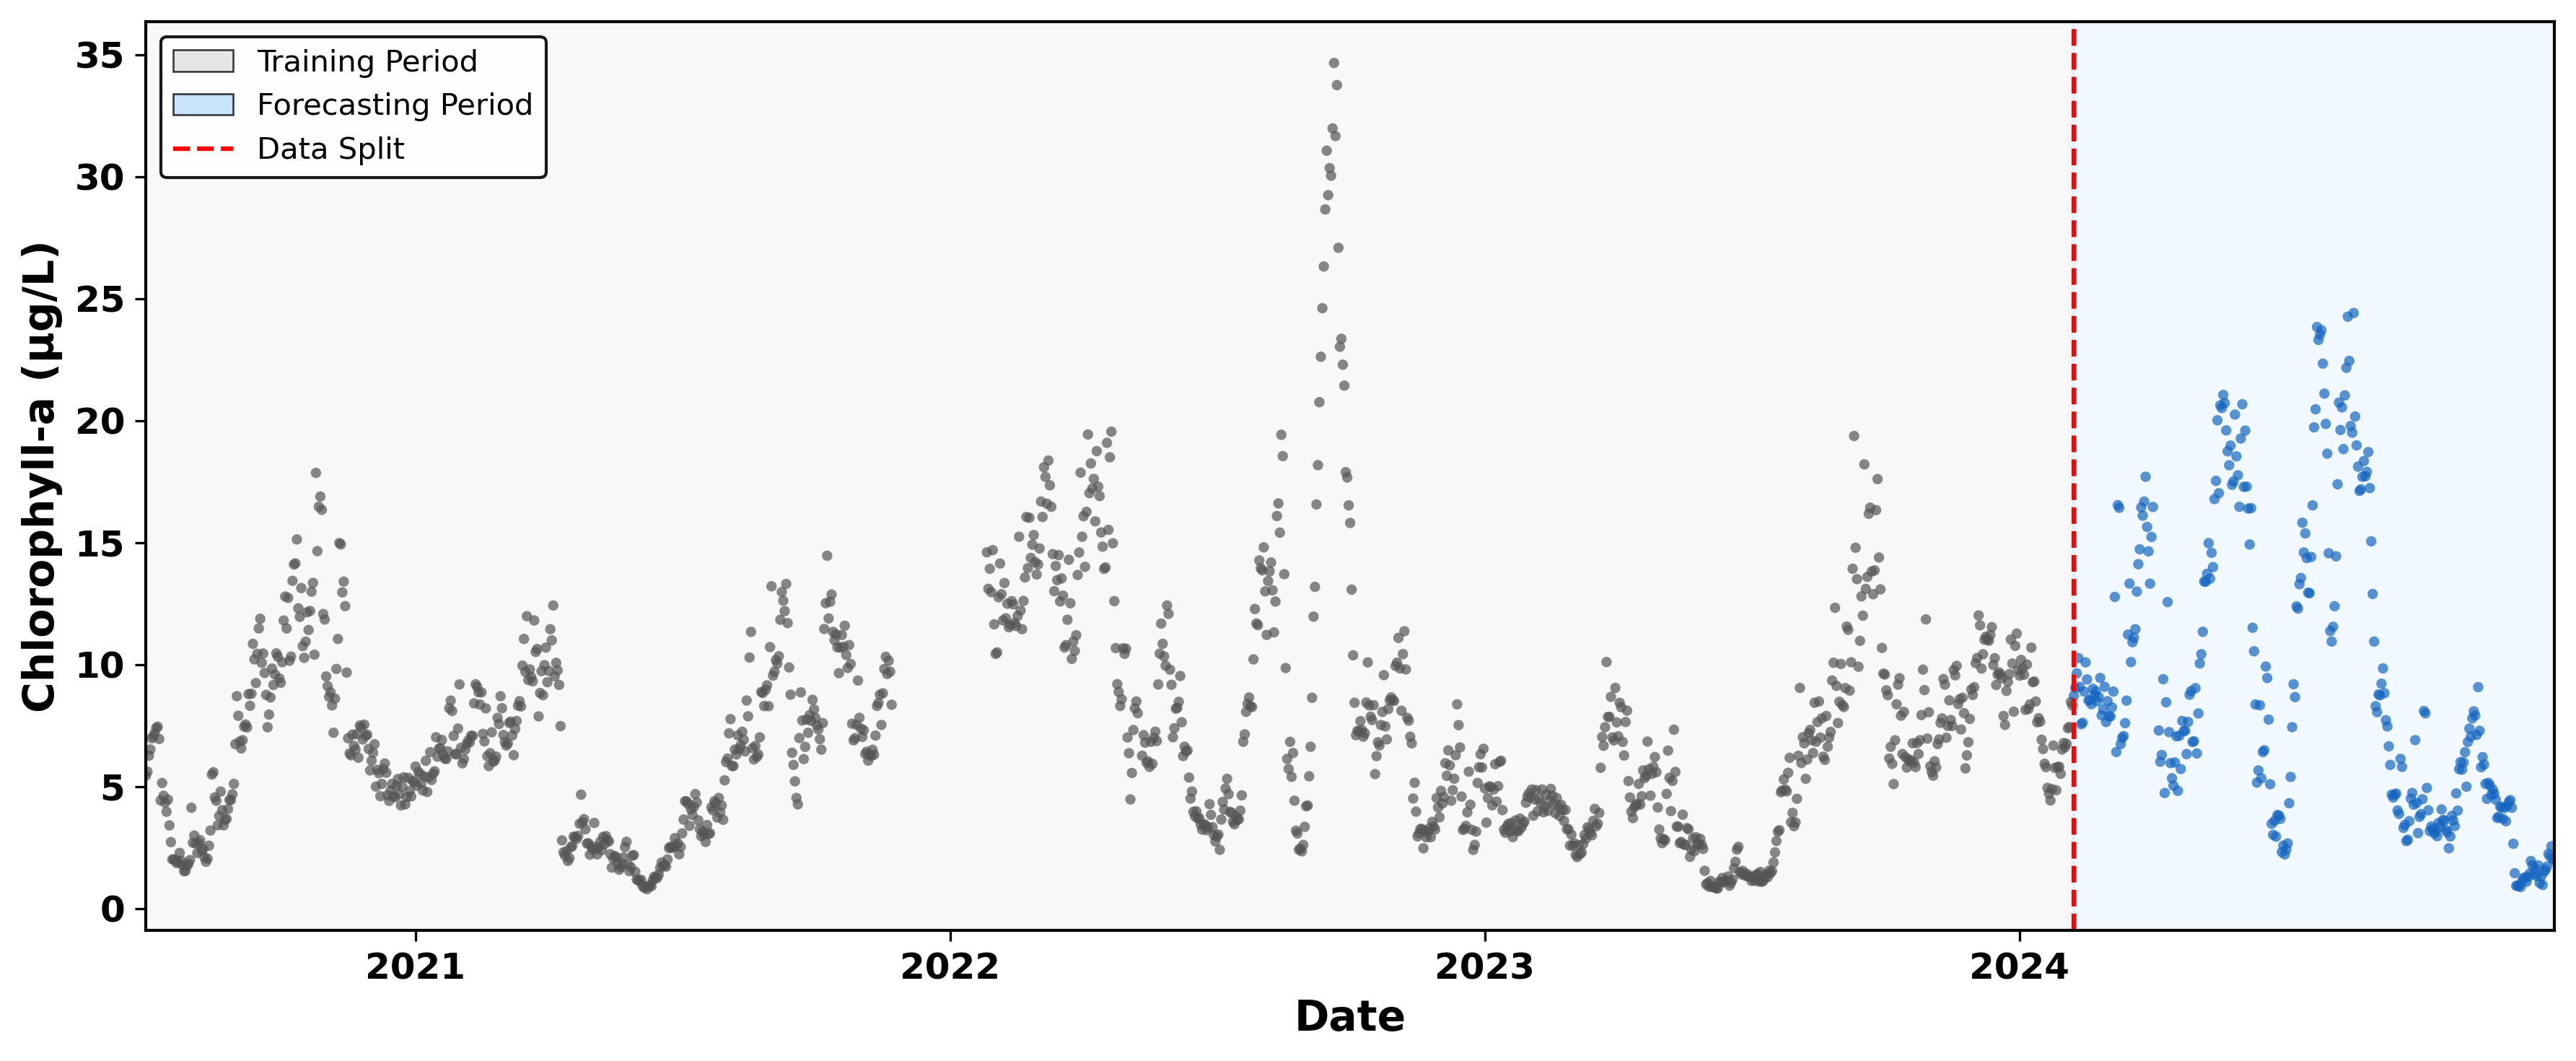

 Saved Chlorophyll-a scatter plot
 CREATING SUPERVISED DATASET - DIRECT MULTI-HORIZON

 INPUT:
 Shape: (1645, 9)
 Date range: 2020-07-01 -> 2024-12-31

 Creating 7-day forecast targets...

 FEATURES (9 total):

 TARGETS (7 horizons):
 SUPERVISED DATASET CREATED


In [5]:
# ------------------------------------------------------------
# CHLOROPHYLL-A SCATTER PLOT and DATA CURATION
# ------------------------------------------------------------
split_idx = int(len(raw_df) * 0.8)
split_date = raw_df.index[split_idx]
fig, ax = plt.subplots(figsize=(12, 5), dpi=300)
data = raw_df[TARGET_COLUMN].dropna()
train_data = data[data.index < split_date]
test_data = data[data.index >= split_date]

#ax.set_xlim(data.index.min(), pd.Timestamp('2025-01-01'))
ax.set_xlim(data.index.min(),data.index.max())

import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


# Background shading
ax.axvspan(raw_df.index.min(), split_date, color='#E0E0E0', alpha=0.2, label='Training Period')
ax.axvspan(split_date, raw_df.index.max(), color='#BBDEFB', alpha=0.2, label='Forecasting Period')
# Split line
ax.axvline(split_date, color='red', linestyle='--', linewidth=1.5, label='Data Split')
# Scatter
ax.scatter(train_data.index, train_data.values, s=12, color='#555555', alpha=0.7, edgecolors='none')
ax.scatter(test_data.index, test_data.values, s=12, color='#1565C0', alpha=0.7, edgecolors='none')
# Labels
ax.set_xlabel('Date', fontsize=14, fontweight='bold')
ax.set_ylabel('Chlorophyll-a (µg/L)', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)
for lab in ax.get_xticklabels() + ax.get_yticklabels():
    lab.set_fontweight('bold')
legend= ax.legend(loc='upper left', fontsize=10, framealpha=0.9, edgecolor='black')
for patch in legend.get_patches():
    patch.set_alpha(0.8)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.6)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
ax.grid(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/exploratory_analysis/chla_timeseries_scatter.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f" Saved Chlorophyll-a scatter plot")

# ------------------------------------------------------------
# CREATE SUPERVISED DATASET
# ------------------------------------------------------------

def create_supervised_dataset_raw(df, target_col, horizons):
    """
    Creates multi-step forecasting targets.
    """
    print(" CREATING SUPERVISED DATASET - DIRECT MULTI-HORIZON")

    print(f"\n INPUT:")
    print(f" Shape: {df.shape}")
    print(f" Date range: {df.index.min().date()} -> {df.index.max().date()}")

    # Create multi-horizon targetS
    print(f"\n Creating {horizons}-day forecast targets...")
    target_forecasts = {}
    for h in range(1, horizons + 1):
        target_forecasts[f"{target_col}_t+{h}"] = df[target_col].shift(-h)

    df_forecasts = pd.DataFrame(target_forecasts, index=df.index)

    # Combine features and targets
    df_supervised = pd.concat([df, df_forecasts], axis=1)
    target_cols = df_forecasts.columns.tolist()

    # Drop rows where ANY target is missing
    before_drop = len(df_supervised)
    df_clean = df_supervised.dropna(subset=target_cols)
    after_drop = len(df_clean)

    # Separate X and y
    feature_cols = df.columns.tolist()
    X = df_clean[feature_cols]
    y = df_clean[target_cols]
    X_missing = X.isnull().sum().sum()
    total_X_cells = X.shape[0] * X.shape[1]


    print(f"\n FEATURES ({len(feature_cols)} total):")
    print(f"\n TARGETS ({len(target_cols)} horizons):")
    print(" SUPERVISED DATASET CREATED")
    return X, y

# Create supervised dataset
X, y = create_supervised_dataset_raw(raw_df, TARGET_COLUMN, FORECAST_HORIZONS)



In [7]:
# ------------------------------------------------------------
# TRAIN-TEST SPLIT (CHRONOLOGICAL) and PREPROCESSING
# ------------------------------------------------------------

print(" CHRONOLOGICAL TRAIN-TEST SPLIT")

# Split data
split_point = int(np.floor(len(X) * TRAIN_RATIO))

X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

print(f"\n Split Ratio: {int(TRAIN_RATIO*100)}/{100-int(TRAIN_RATIO*100)}")
print(f"\nTrain Set:")
print(f" Period: {X_train.index.min().date()} -> {X_train.index.max().date()}")
print(f" Samples: {len(X_train):,}")
#print(f" X shape: {X_train.shape}")
#print(f" y shape: {y_train.shape}")

print(f"\nTest Set:")
print(f" Period: {X_test.index.min().date()} -> {X_test.index.max().date()}")
print(f" Samples: {len(X_test):,}")
#print(f" X shape: {X_test.shape}")
#print(f" y shape: {y_test.shape}")

print(" CHRONOLOGICAL SPLIT COMPLETE")

# ------------------------------------------------------------
# PREPROCESSING
# ------------------------------------------------------------

print("Preprocessing started!")
# Create simple pipeline: scaling only
preprocessor = Pipeline([
    ('scaler', StandardScaler()) # Skips NaN in mean/std calculation
])
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert back to DataFrame
X_train_processed = pd.DataFrame(
    X_train_processed,
    index=X_train.index,
    columns=X_train.columns
)
X_test_processed = pd.DataFrame(
    X_test_processed,
    index=X_test.index,
    columns=X_test.columns
)
print("Preprocessing complete!")

 CHRONOLOGICAL TRAIN-TEST SPLIT

 Split Ratio: 80/20

Train Set:
 Period: 2020-07-01 -> 2024-02-08
 Samples: 1,240

Test Set:
 Period: 2024-02-09 -> 2024-12-24
 Samples: 311
 CHRONOLOGICAL SPLIT COMPLETE
Preprocessing started!
Preprocessing complete!


In [9]:
# ------------------------------------------------------------
# HYPERPARAMETER OPTIMIZATION (OPTUNA)
# ------------------------------------------------------------

def objective(trial, X, y):
    """
    Optuna objective function with regularization
    """

    params = {
        "objective": "reg:squarederror",
        "random_state": SEED,
        "n_jobs": 1,
        "tree_method": "hist",
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 10, 50),
        "gamma": trial.suggest_float("gamma", 0.5, 2.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 2.0, 10.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 2.0, 10.0),
        "subsample": trial.suggest_float("subsample", 0.6, 0.8),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.8),
    }

    estimator = MultiOutputRegressor(xgb.XGBRegressor(**params))

    # Time-series cross-validation
    tscv = TimeSeriesSplit(n_splits=CV_SPLITS)
    rmses = []

    for train_idx, val_idx in tscv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        estimator.fit(X_tr, y_tr)
        y_pred = estimator.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        rmses.append(rmse)

    return float(np.mean(rmses))
print(" HYPERPARAMETER OPTIMIZATION")

print(f"\n Starting Optuna with {OPTUNA_TRIALS} trials and {CV_SPLITS}-fold CV...")
print(f" This will take approximately 8-10 minutes...")
print(f" Progress bar will show below:\n")

optuna.logging.set_verbosity(optuna.logging.WARNING)
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="minimize", sampler=sampler)

study.optimize(
    lambda trial: objective(trial, X_train_processed, y_train),
    n_trials=OPTUNA_TRIALS,
    show_progress_bar=True
)

print("\n HPO Complete!")
print("\n BEST TRIAL:")
print(f" RMSE (CV mean): {study.best_value:.4f} µg/L")
print(f"\n Best parameters (Enhanced Regularization):")
for k, v in study.best_params.items():
    print(f" {k}: {v}")

# Save trials
trials_df = study.trials_dataframe()
trials_df.to_csv(f'{OUTPUT_DIR}/optuna_trials.csv', index=False)
print(f"\n Saved: {OUTPUT_DIR}/optuna_trials.csv")


 HYPERPARAMETER OPTIMIZATION

 Starting Optuna with 50 trials and 5-fold CV...
 This will take approximately 8-10 minutes...
 Progress bar will show below:



  0%|          | 0/50 [00:00<?, ?it/s]


 HPO Complete!

 BEST TRIAL:
 RMSE (CV mean): 3.0728 µg/L

 Best parameters (Enhanced Regularization):
 n_estimators: 178
 max_depth: 6
 learning_rate: 0.023995776775647334
 min_child_weight: 47
 gamma: 1.8226122896589338
 reg_alpha: 8.250816518723832
 reg_lambda: 7.288147935633978
 subsample: 0.6341205970243599
 colsample_bytree: 0.7922947227941242

 Saved: ./BVR_Forecasting_Results/optuna_trials.csv


In [11]:
# ------------------------------------------------------------
# TRAIN FINAL MODEL WITH BEST PARAMETERS
# ------------------------------------------------------------

print(" TRAINING FINAL MODEL")

best_params = study.best_params
final_xgboost = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist",
    **best_params
)

final_model = MultiOutputRegressor(final_xgboost)
final_model.fit(X_train_processed, y_train)

print(" Model trained successfully!")
print(f"\n Model Structure:")
print(f" Type: MultiOutputRegressor")
print(f" Base Estimator: XGBoost")
print(f" Each estimator predicts: One horizon independently")
print(" FINAL MODEL TRAINED AND READY FOR EVALUATION")

# ------------------------------------------------------------
# MODEL EVALUATION
# ------------------------------------------------------------

def evaluate_model(model, X_test, y_test):
    """Calculate performance metrics for each horizon."""

    y_pred = model.predict(X_test)
    metrics_rows = []
    print(" PERFORMANCE BY HORIZON")


    for i in range(y_test.shape[1]):
        y_true_h = y_test.iloc[:, i]
        y_pred_h = y_pred[:, i]

        rmse = np.sqrt(mean_squared_error(y_true_h, y_pred_h))
        mae = mean_absolute_error(y_true_h, y_pred_h)
        r2 = r2_score(y_true_h, y_pred_h)
        corr = np.corrcoef(y_true_h, y_pred_h)[0, 1]

        metrics_rows.append({
            "Horizon": f"{i+1}-day",
            "RMSE": round(rmse, 4),
            "MAE": round(mae, 4),
           # "R²": round(r2, 4),
            "Correlation": round(corr, 4),
        })

        print(f"Horizon {i+1}: RMSE={rmse:.4f}, MAE={mae:.4f},Corr={corr:.4f}")

    return pd.DataFrame(metrics_rows)

# Evaluate on test set
metrics_df = evaluate_model(final_model, X_test_processed, y_test)

print(f"\n SUMMARY STATISTICS:")
print(f" Average RMSE: {metrics_df['RMSE'].mean():.4f} µg/L")
print(f" Average MAE: {metrics_df['MAE'].mean():.4f} µg/L")
print(f" Average Corr: {metrics_df['Correlation'].mean():.4f}")

print(" MODEL EVALUATION COMPLETE")

# Save metrics
metrics_df.to_csv(f'{OUTPUT_DIR}/test_metrics_by_horizon.csv', index=False)
print(f"\n Saved: {OUTPUT_DIR}/test_metrics_by_horizon.csv")

# Display table
#print("\n Performance Table:")
#display(metrics_df)

 TRAINING FINAL MODEL
 Model trained successfully!

 Model Structure:
 Type: MultiOutputRegressor
 Base Estimator: XGBoost
 Each estimator predicts: One horizon independently
 FINAL MODEL TRAINED AND READY FOR EVALUATION
 PERFORMANCE BY HORIZON
Horizon 1: RMSE=1.9613, MAE=1.3997,Corr=0.9489
Horizon 2: RMSE=2.4621, MAE=1.7952,Corr=0.9182
Horizon 3: RMSE=2.7758, MAE=2.0963,Corr=0.8942
Horizon 4: RMSE=3.1038, MAE=2.3878,Corr=0.8675
Horizon 5: RMSE=3.4127, MAE=2.6816,Corr=0.8379
Horizon 6: RMSE=3.5555, MAE=2.8313,Corr=0.8282
Horizon 7: RMSE=3.7903, MAE=3.0279,Corr=0.8082

 SUMMARY STATISTICS:
 Average RMSE: 3.0088 µg/L
 Average MAE: 2.3171 µg/L
 Average Corr: 0.8719
 MODEL EVALUATION COMPLETE

 Saved: ./BVR_Forecasting_Results/test_metrics_by_horizon.csv


 7-DAY SHAP ANALYSIS + STACKED PROPORTIONAL IMPORTANCE
 Computing SHAP values for 7-day horizon...
 SHAP computed: (311, 9)

 7-DAY FEATURE IMPORTANCE:
                               Feature Feature_Abbrev  Mean_|SHAP|
              BVR_mean_EXOChla_ugL_1.5          Chl-a     3.140007
              BVR_mean_EXOfDOM_QSU_1.5           fDOM     0.945397
            BVR_mean_schmidt_stability             SS     0.359169
                BVR_mean_EXOTemp_C_1.5     Water Temp     0.288974
mean_ShortwaveRadiationUp_Average_W_m2             SW     0.205334
                mean_AirTemp_C_Average       Air Temp     0.191823
            BVR_mean_RDOsat_percent_13        Deep DO     0.114366
            mean_WindSpeed_Average_m_s             WS     0.053193
                     sum_Rain_Total_mm  Precipitation     0.029039

 Generating 7-day SHAP summary plot...


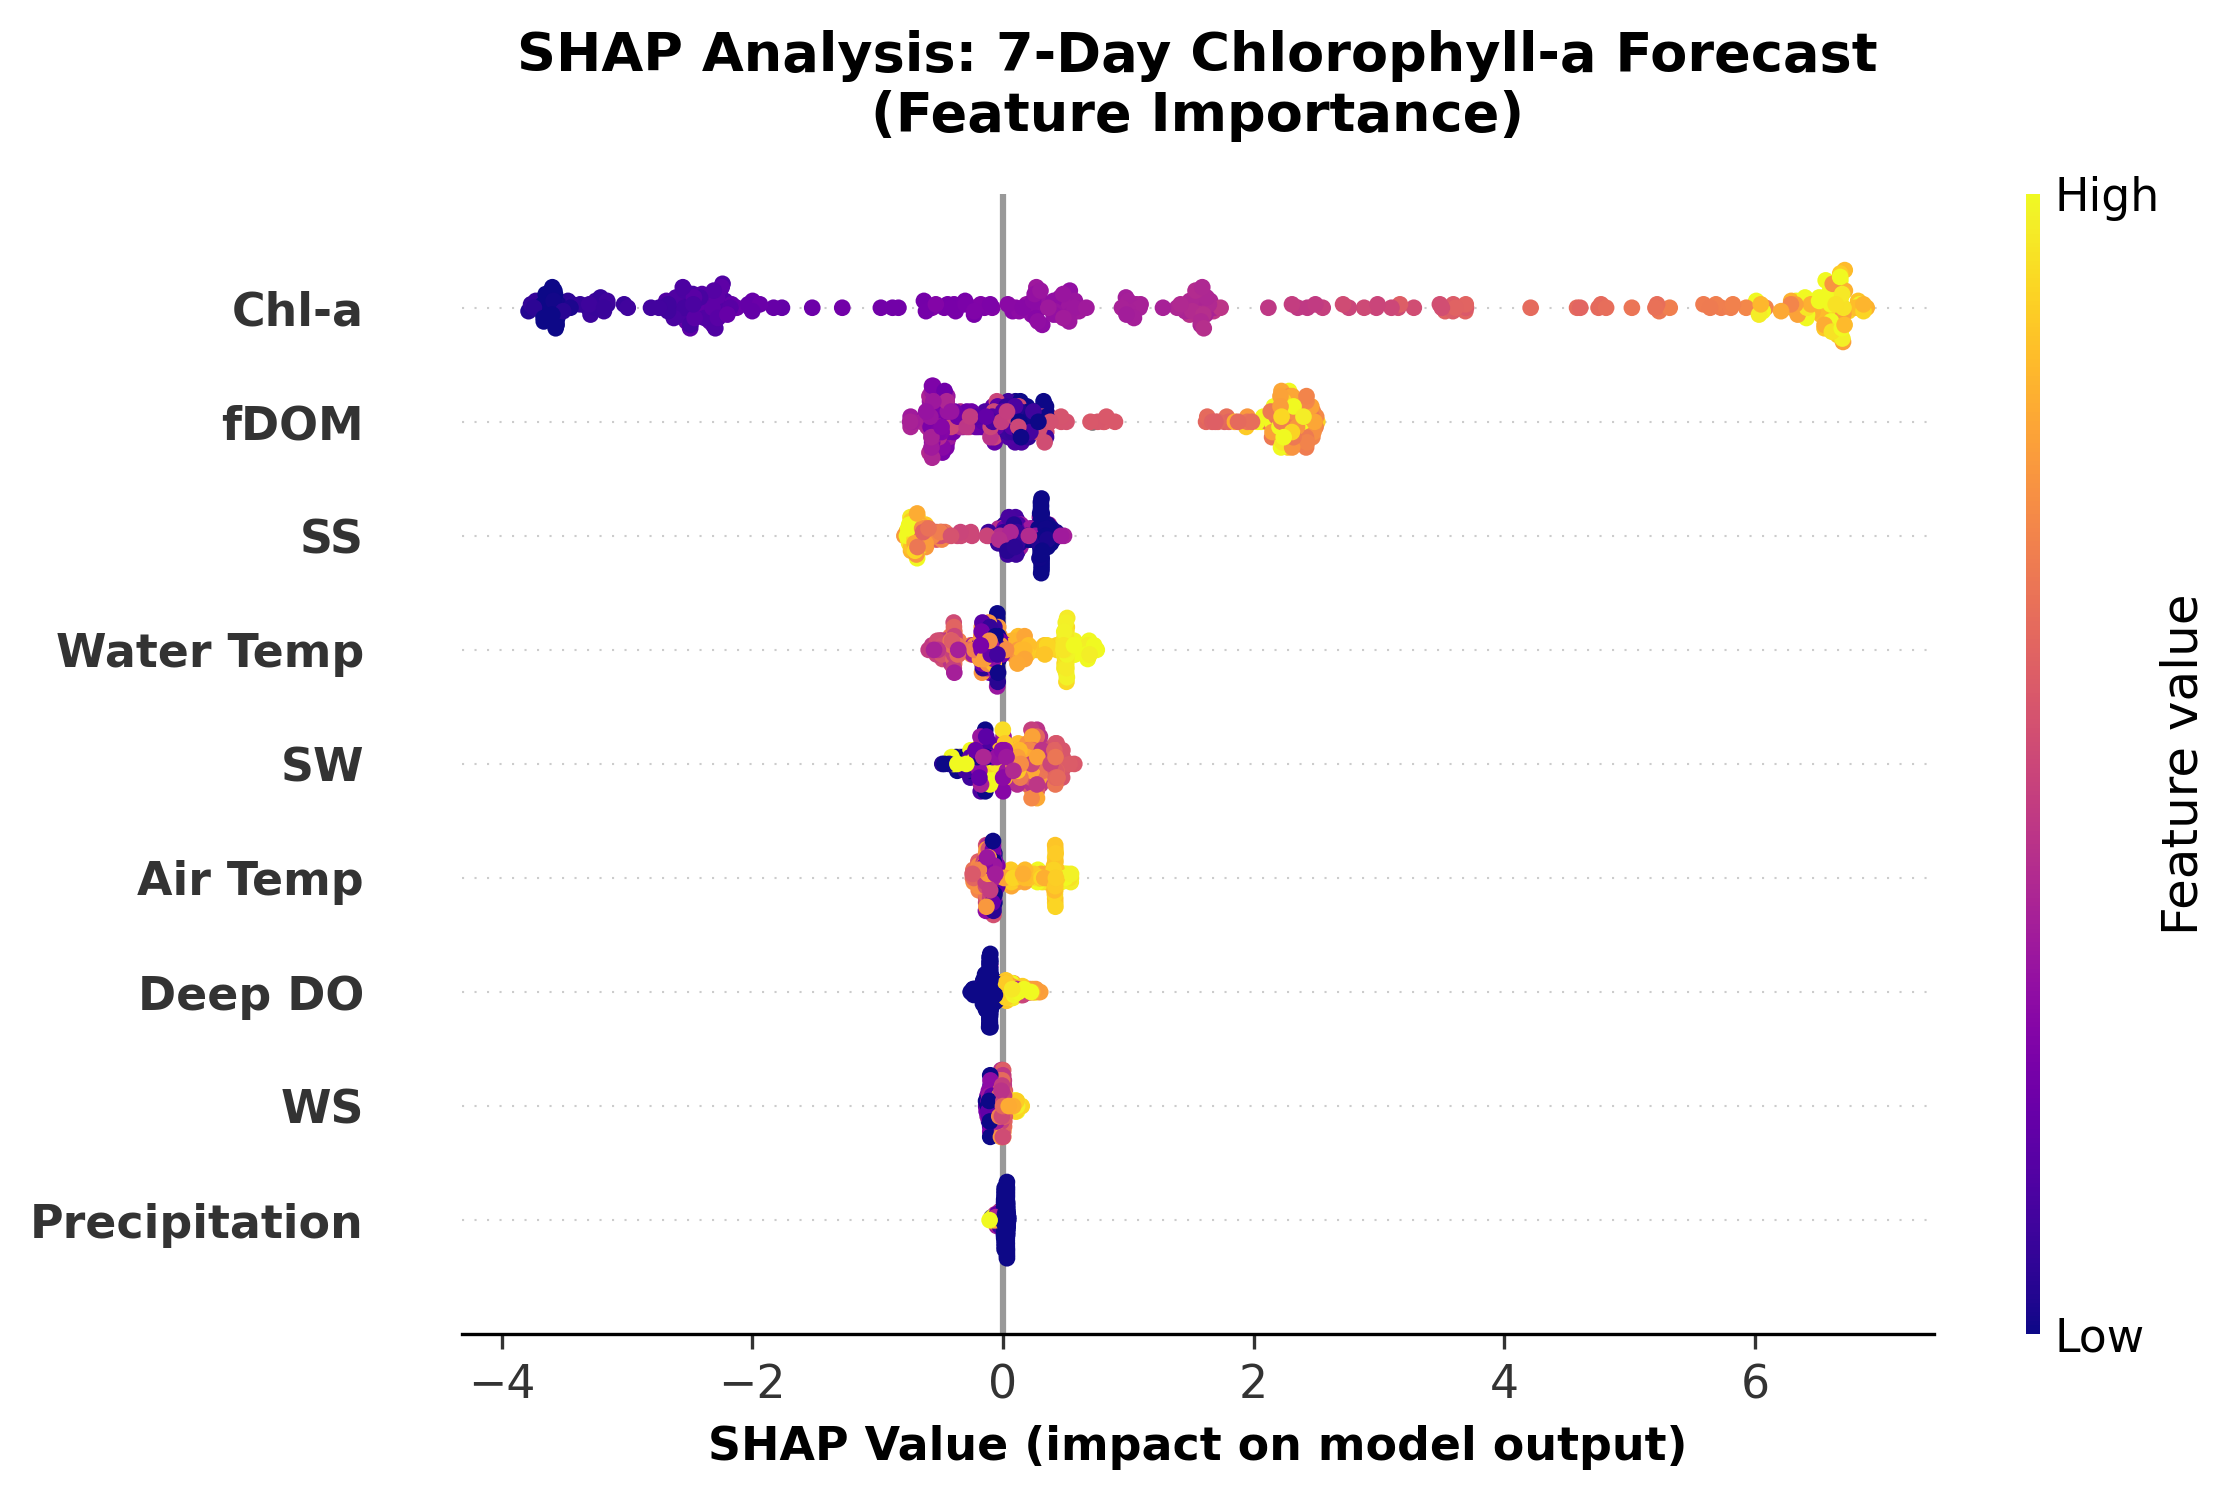

 Saved: ./shap_7day_viridis.png

 Computing SHAP values for all horizons...
 SHAP for all horizons computed: (7, 9)

 Generating stacked proportional importance chart...


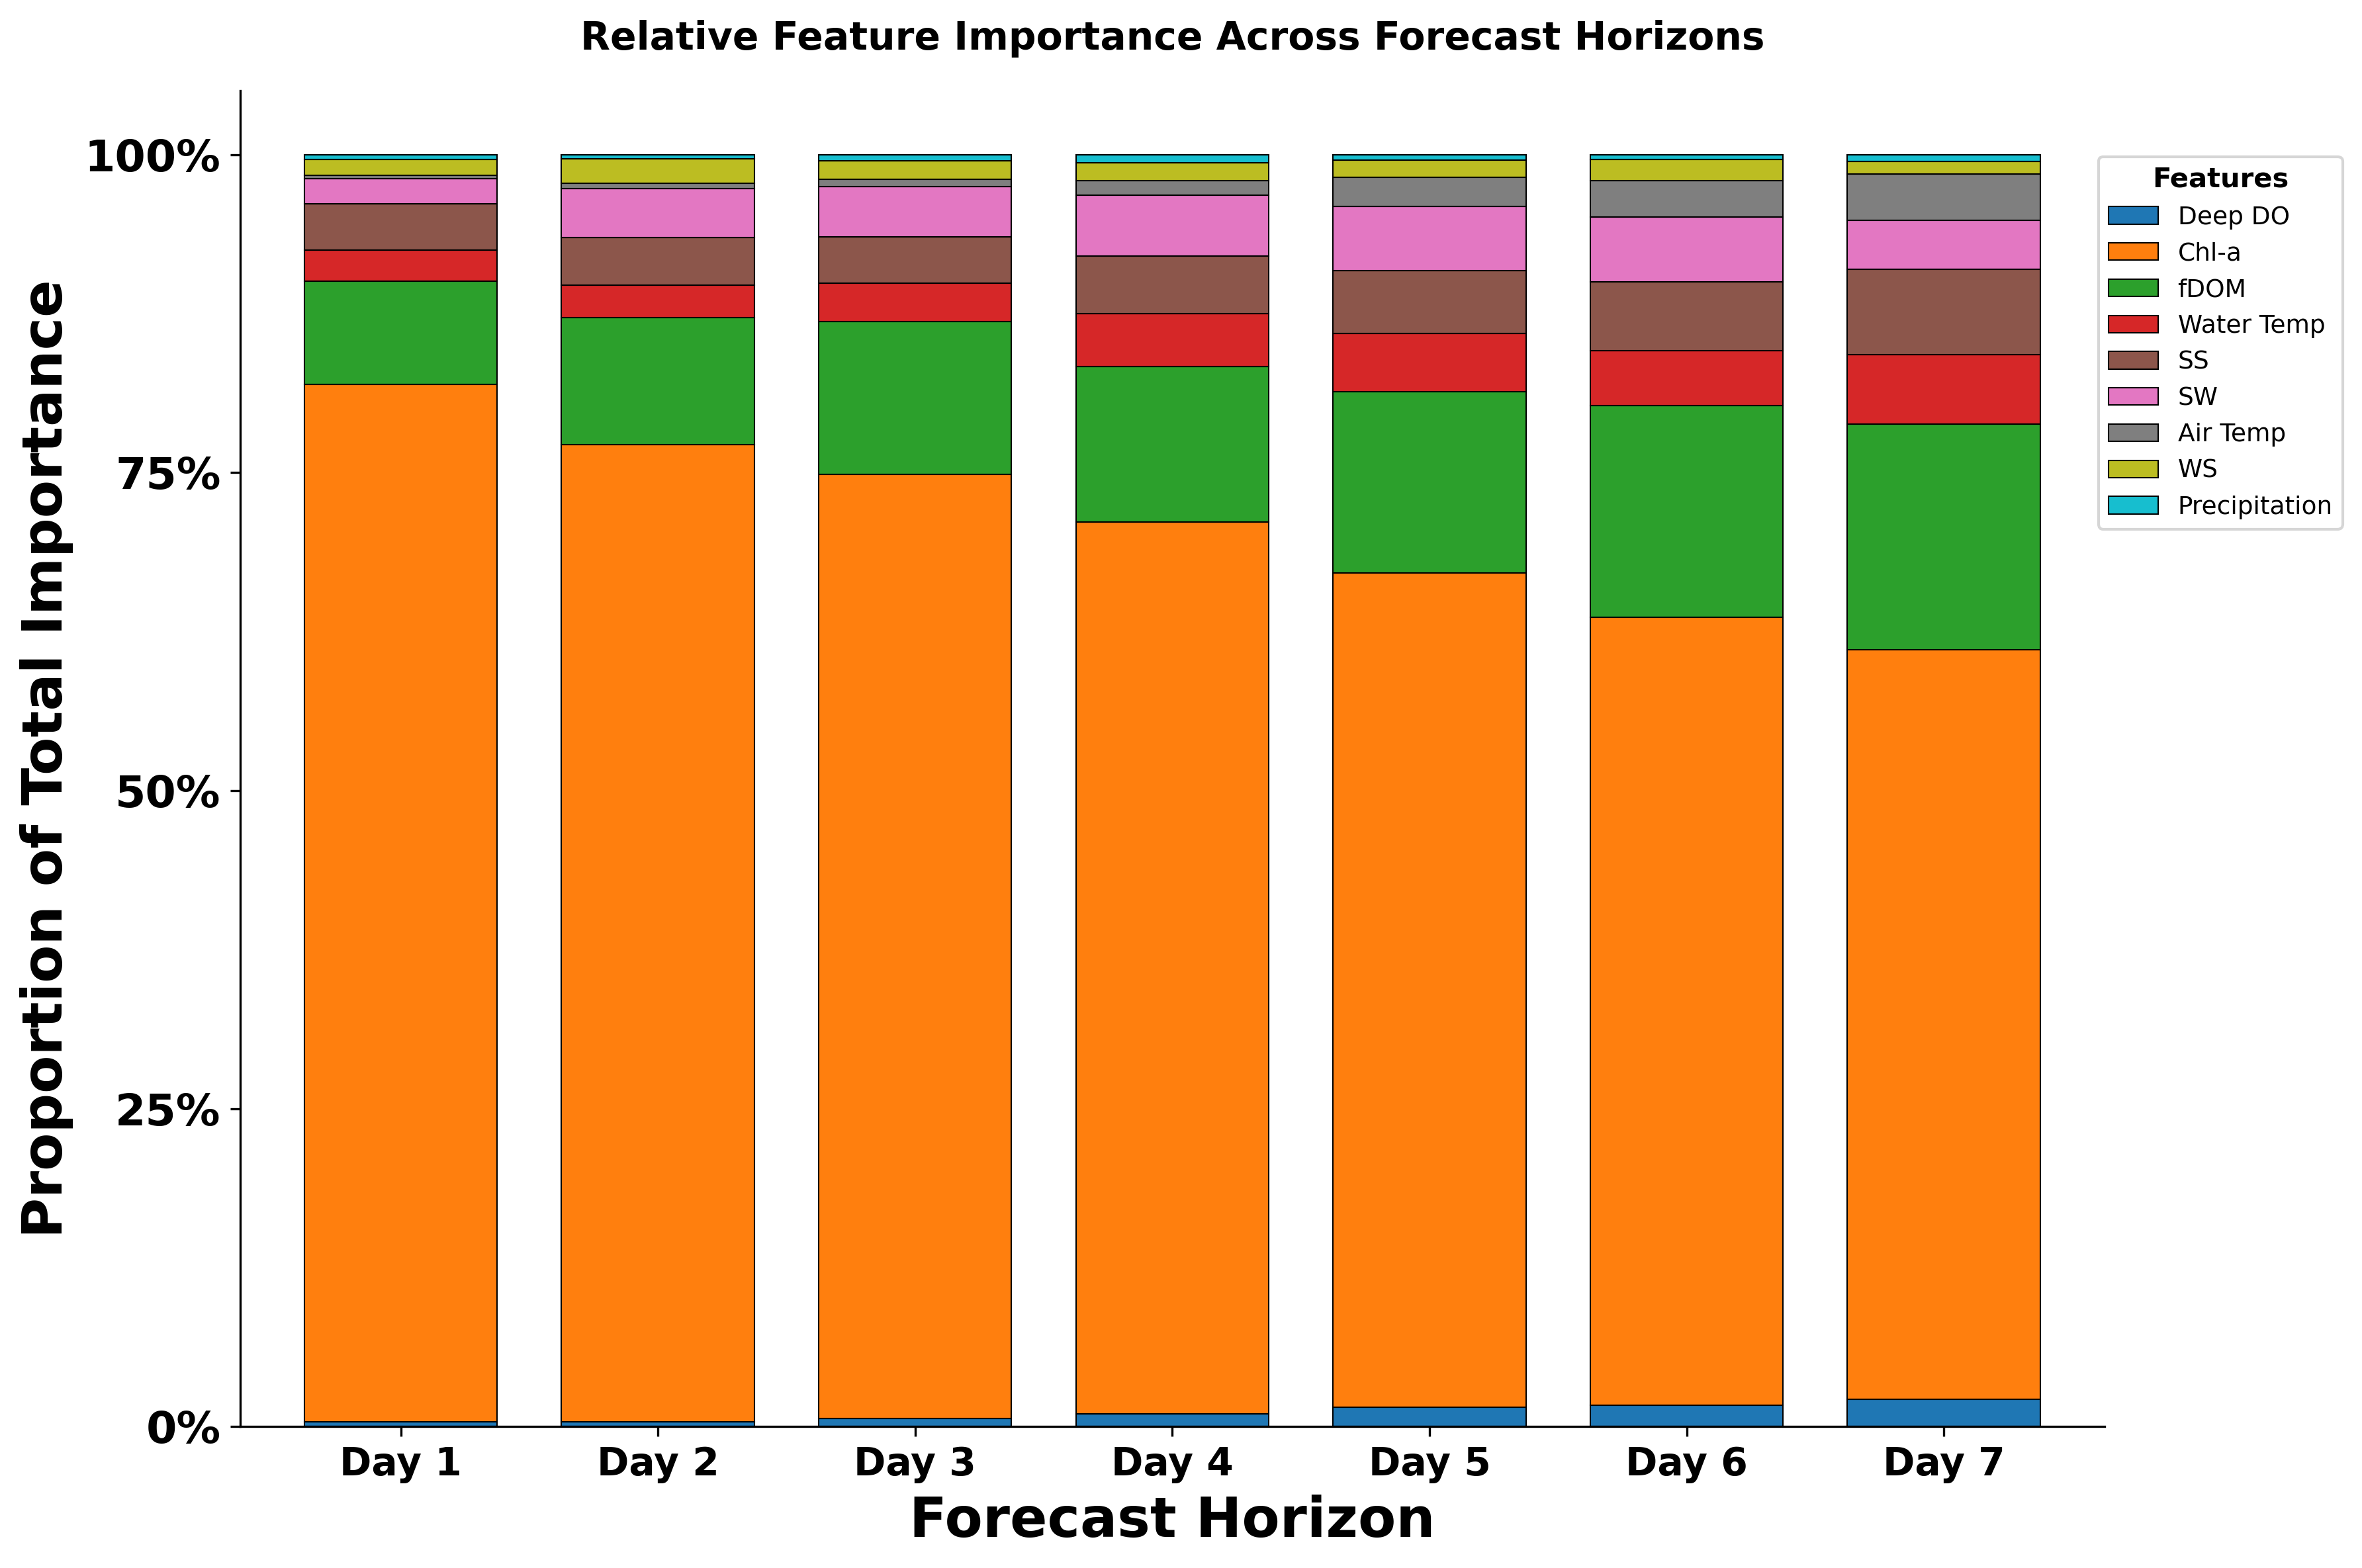

 Saved: ./shap_stacked_proportions.png
 ANALYSIS COMPLETE (Saved figures in current directory)

 FILES GENERATED:
 1. shap_7day_viridis.png
 2. shap_stacked_proportions.png


In [13]:
# ------------------------------------------------------------
# SHAP 7-DAY ANALYSIS + STACKED PROPORTIONAL IMPORTANCE
# ------------------------------------------------------------

print(" 7-DAY SHAP ANALYSIS + STACKED PROPORTIONAL IMPORTANCE")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# ============================================================================
# Feature Abbreviation Map
# ============================================================================
FEATURE_ABBREV_MAP = {
    'BVR_mean_EXOChla_ugL_1.5': 'Chl-a',
    'BVR_mean_EXOfDOM_QSU_1.5': 'fDOM',
    'BVR_mean_EXOTemp_C_1.5': 'Water Temp',
    'BVR_mean_schmidt_stability': 'SS',
    'BVR_mean_RDOsat_percent_13': 'Deep DO',
    'mean_ShortwaveRadiationUp_Average_W_m2': 'SW',
    'mean_AirTemp_C_Average': 'Air Temp',
    'mean_WindSpeed_Average_m_s': 'WS',
    'sum_Rain_Total_mm': 'Precipitation'
}

# ============================================================================
# Compute SHAP for 7-Day Horizon ONLY
# ============================================================================
print(" Computing SHAP values for 7-day horizon...")

# Get 7-day model (last horizon)
model_7d = final_model.estimators_[-1]
explainer_7d = shap.TreeExplainer(model_7d)

X_shap = X_test_processed
shap_values_7d = explainer_7d.shap_values(X_shap) # shape: (N_samples, N_features)

print(f" SHAP computed: {shap_values_7d.shape}\n")

# ============================================================================
# Get Feature Importance Ranking (7-day)
# ============================================================================
mean_abs_shap_7d = np.abs(shap_values_7d).mean(axis=0)

shap_importance_7d = pd.DataFrame({
    'Feature': X_test_processed.columns,
    'Feature_Abbrev': [FEATURE_ABBREV_MAP.get(f, f) for f in X_test_processed.columns],
    'Mean_|SHAP|': mean_abs_shap_7d
}).sort_values('Mean_|SHAP|', ascending=False)

print(" 7-DAY FEATURE IMPORTANCE:")
print(shap_importance_7d.to_string(index=False))
print()

# Save the table;
# shap_importance_7d.to_csv(f'{OUTPUT_DIR}/shap_7day_importance.csv', index=False)

# ============================================================================
# SHAP Summary Plot (7-Day)
# ============================================================================
print(" Generating 7-day SHAP summary plot...")

plt.figure(figsize=(10, 7), dpi=300)
shap.summary_plot(
    shap_values_7d,
    X_shap,
    show=False,
    max_display=10,
    cmap=plt.get_cmap('plasma')
)

# Apply abbreviated y-tick labels
ax = plt.gca()
yticklabels = ax.get_yticklabels()
new_labels = [FEATURE_ABBREV_MAP.get(lbl.get_text(), lbl.get_text())
              for lbl in yticklabels]
ax.set_yticklabels(new_labels, fontweight='bold', fontsize=11)

plt.title('SHAP Analysis: 7-Day Chlorophyll-a Forecast\n(Feature Importance)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('SHAP Value (impact on model output)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_7day_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: ./shap_7day_viridis.png\n")

# ============================================================================
# Compute SHAP for ALL Horizons (for Stacked Bar Chart)
# ============================================================================
print(" Computing SHAP values for all horizons...")
mean_abs_shap_all_horizons = []

for h_idx in range(FORECAST_HORIZONS):
    # Get model for current horizon
    model_h = final_model.estimators_[h_idx]
    explainer_h = shap.TreeExplainer(model_h)

    # Compute SHAP values
    shap_values_h = explainer_h.shap_values(X_shap)

    # Get mean absolute SHAP for this horizon
    mean_abs_shap_h = np.abs(shap_values_h).mean(axis=0)
    mean_abs_shap_all_horizons.append(mean_abs_shap_h)

mean_abs_shap = np.array(mean_abs_shap_all_horizons) # This is the missing variable
print(f" SHAP for all horizons computed: {mean_abs_shap.shape}\n")


# ============================================================================
# Stacked Bar Chart - Relative Feature Importance
# ============================================================================
print(" Generating stacked proportional importance chart...")

n_h, n_f = mean_abs_shap.shape
feature_names_full = list(X_test_processed.columns)[:n_f] # align to matrix width
feature_names_abbrev = [FEATURE_ABBREV_MAP.get(f, f) for f in feature_names_full]
horizon_labels = [f'Day {i+1}' for i in range(n_h)]

# Normalize SHAP values to proportions (row-wise per horizon)
normalized_shap = mean_abs_shap / mean_abs_shap.sum(axis=1, keepdims=True)

# DataFrame with abbreviated names
df_normalized = pd.DataFrame(
    normalized_shap,
    index=horizon_labels,
    columns=feature_names_abbrev
)

fig, ax = plt.subplots(figsize=(12, 8), dpi=300)
df_normalized.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    cmap='tab10',
    width=0.75,
    edgecolor='black',
    linewidth=0.5
)

ax.set_title('Relative Feature Importance Across Forecast Horizons',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Forecast Horizon', fontsize=20, fontweight='bold')
for tick in ax.get_xticklabels():
    tick.set_fontweight('bold')
    tick.set_fontsize(14)
ax.set_ylabel('Proportion of Total Importance', fontsize=20, fontweight='bold')
ax.set_xticklabels(horizon_labels, rotation=0, fontweight='bold')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=16, fontweight='bold')
ax.legend(title='Features', bbox_to_anchor=(0.99, 0.96), loc='upper left',
          frameon=True, shadow=False, fontsize=9,
          title_fontproperties={'weight': 'bold', 'size': 10})
#ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('shap_stacked_proportions.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: ./shap_stacked_proportions.png")

# ============================================================================
# Summary
# ============================================================================
print(" ANALYSIS COMPLETE (Saved figures in current directory)")
print("\n FILES GENERATED:")
print(" 1. shap_7day_viridis.png")
print(" 2. shap_stacked_proportions.png")



Horizon-wise Pearson r (Train vs Test):
1-day: Train r = 0.9453 | Test r = 0.9489
2-day: Train r = 0.9238 | Test r = 0.9182
3-day: Train r = 0.9055 | Test r = 0.8942
4-day: Train r = 0.8891 | Test r = 0.8675
5-day: Train r = 0.8767 | Test r = 0.8379
6-day: Train r = 0.8611 | Test r = 0.8282
7-day: Train r = 0.8476 | Test r = 0.8082


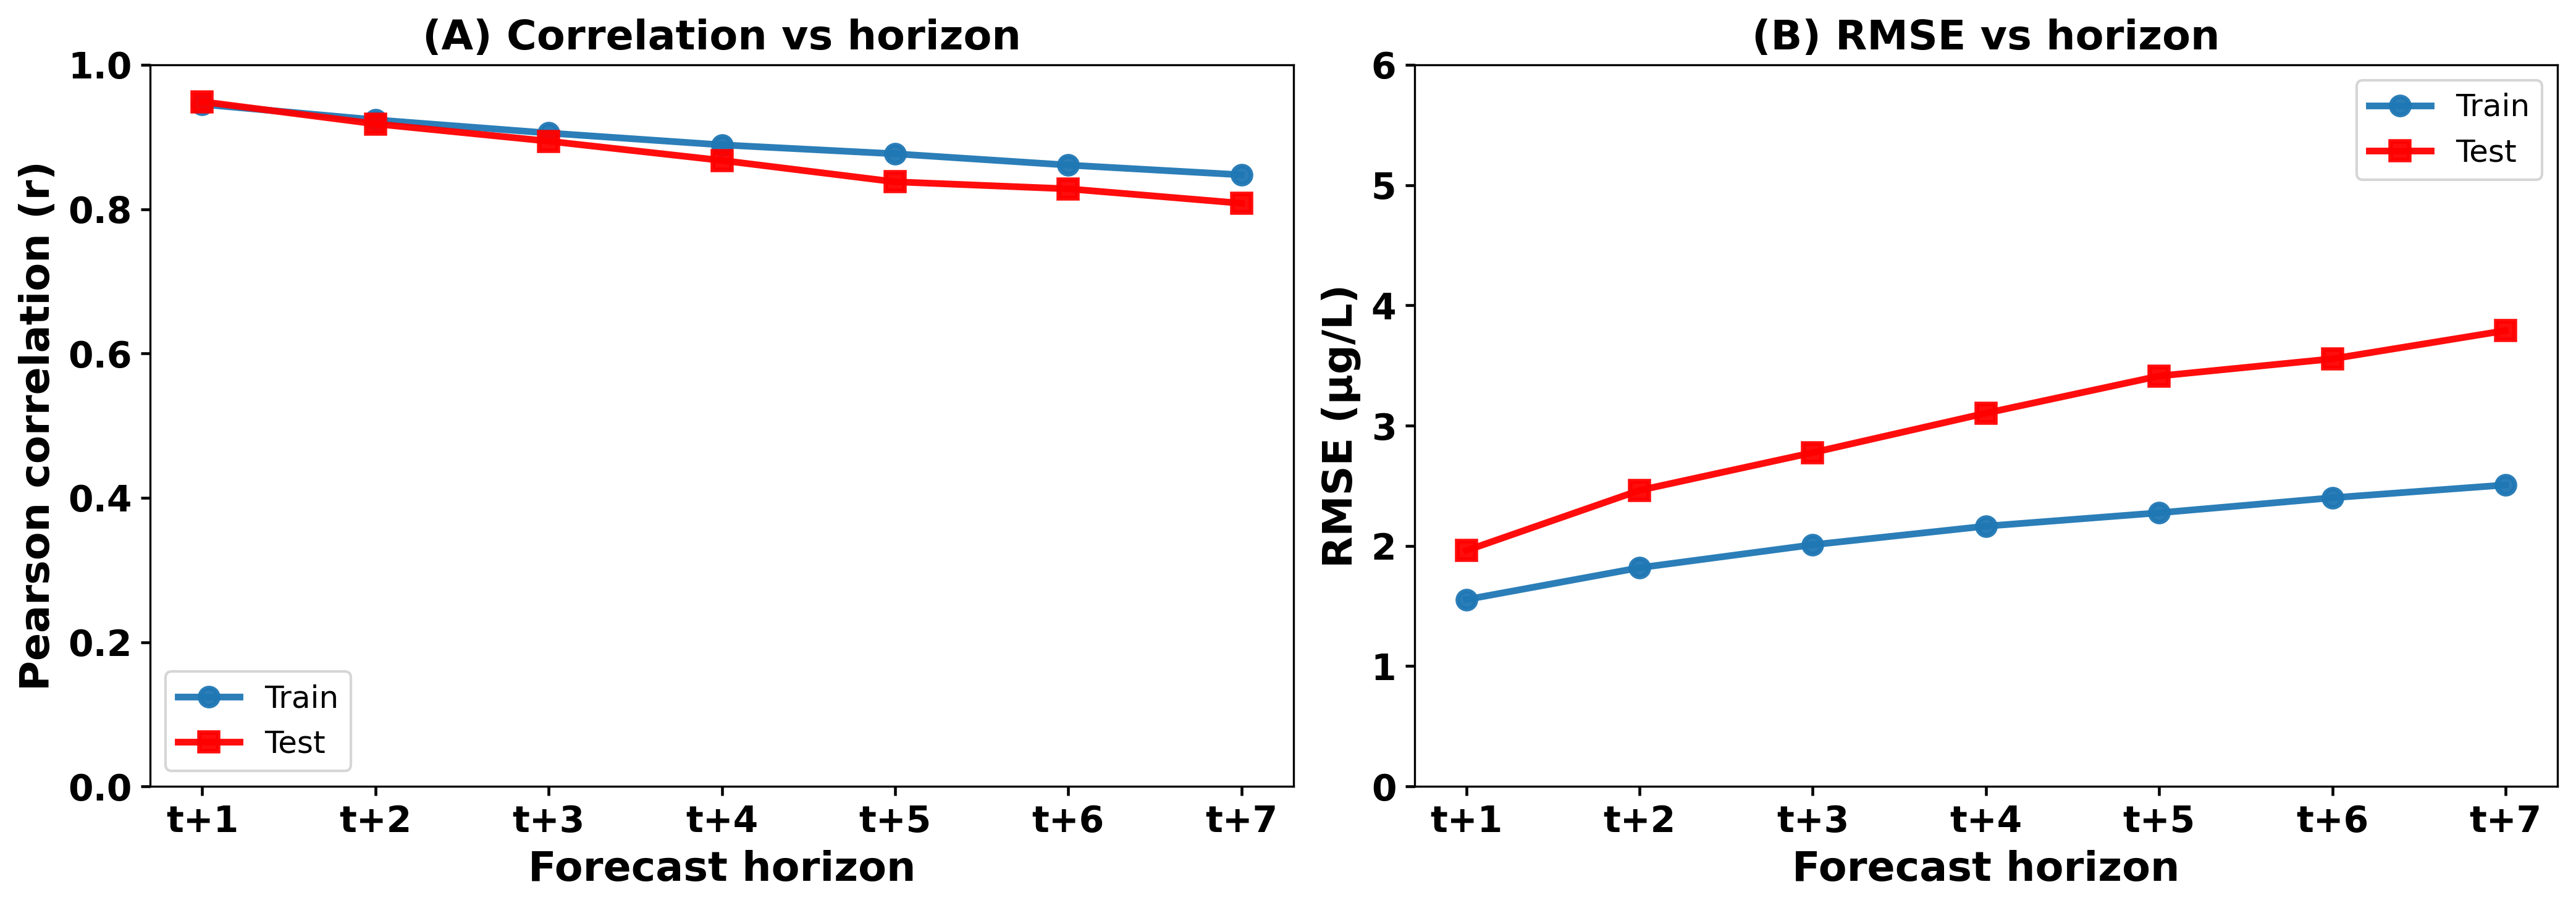

 Saved: ./BVR_Forecasting_Results/performance_curves_r_rmse_train_test.png


In [15]:
# ============================================================================
# LINE PERFORMANCE CURVES ACROSS HORIZONS (TRAIN VS TEST)
# PURPOSE: Show horizon-wise "time-series" trends of r and RMSE
# ============================================================================

def safe_corr(a, b):
    a = np.asarray(a); b = np.asarray(b)
    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return np.corrcoef(a, b)[0, 1]

# Compute predictions for train and test sets
y_train_pred = final_model.predict(X_train_processed)
y_test_pred = final_model.predict(X_test_processed)

# Initialize lists for metrics
train_rmse = []
test_rmse = []
train_corr = []
test_corr = []

# Calculate metrics for each forecast horizon
for i in range(FORECAST_HORIZONS):
    # RMSE
    train_rmse.append(np.sqrt(mean_squared_error(y_train.iloc[:, i], y_train_pred[:, i])))
    test_rmse.append(np.sqrt(mean_squared_error(y_test.iloc[:, i], y_test_pred[:, i])))

    # Correlation
    train_corr.append(safe_corr(y_train.iloc[:, i], y_train_pred[:, i]))
    test_corr.append(safe_corr(y_test.iloc[:, i], y_test_pred[:, i]))


h_idx = np.arange(1, FORECAST_HORIZONS + 1)
h_labels = [f"t+{i}" for i in h_idx]


fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

# Common styling
for ax in axes:
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.tick_params(axis="both", labelsize=10, width=1.1)
    for lab in ax.get_xticklabels() + ax.get_yticklabels():
        lab.set_fontweight("bold")

# --- Panel A: Pearson r across horizons ---
axes[0].plot(
    h_idx, train_corr,
    linestyle="-", color="#1f77b4", linewidth=2.6, marker="o", markersize=7,
    markerfacecolor="#1f77b4", markeredgewidth=1.8,
    label="Train", alpha=0.95
)
axes[0].plot(
    h_idx, test_corr,
    linestyle="-", color="red", linewidth=2.6, marker="s", markersize=7,
    markerfacecolor="red", markeredgewidth=1.8,
    label="Test", alpha=0.95
)

axes[0].set_xticks(h_idx)
axes[0].set_xticklabels(h_labels)
axes[0].set_ylim(0, 1.0)
axes[0].set_xlabel("Forecast horizon", fontsize=16, fontweight="bold")
axes[0].set_ylabel("Pearson correlation (r)", fontsize=16, fontweight="bold")
axes[0].set_title("(A) Correlation vs horizon", fontsize=16, fontweight="bold")
axes[0].legend(frameon=True, fontsize=12)

# --- Panel B: RMSE across horizons ---
axes[1].plot(
    h_idx, train_rmse,
    linestyle="-", color="#1f77b4", linewidth=2.6, marker="o", markersize=7,
    markerfacecolor="#1f77b4", markeredgewidth=1.8,
    label="Train", alpha=0.95
)
axes[1].plot(
    h_idx, test_rmse,
    linestyle="-",color="red", linewidth=2.6, marker="s", markersize=7,
    markerfacecolor="red", markeredgewidth=1.8,
    label="Test", alpha=0.95
)

axes[1].set_xticks(h_idx)
axes[1].set_xticklabels(h_labels)
axes[1].set_xlabel("Forecast horizon", fontsize=16, fontweight="bold")
axes[1].set_ylabel("RMSE (µg/L)", fontsize=16, fontweight="bold")
axes[1].set_title("(B) RMSE vs horizon", fontsize=16, fontweight="bold")
axes[1].set_ylim(0, 6)
axes[1].legend(frameon=True, fontsize=12)

axes[1].legend(frameon=True, fontsize=12)

for ax in axes:
    ax.tick_params(axis="both", labelsize=14)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight("bold")

plt.tight_layout()


# Print horizon-wise r (train/test)
print("\nHorizon-wise Pearson r (Train vs Test):")
for h in range(FORECAST_HORIZONS):
    print(f"{h+1}-day: Train r = {train_corr[h]:.4f} | Test r = {test_corr[h]:.4f}")


out_path = f"{OUTPUT_DIR}/performance_curves_r_rmse_train_test.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f" Saved: {out_path}")

 CUSTOM INSTANCE PLOTS BY DATE (TWO INSTANCES)

 INSTANCE 1/2: 2024-06-04

 Looking for date: 2024-06-04
 Date: 2024-06-04

 Creating line plot...


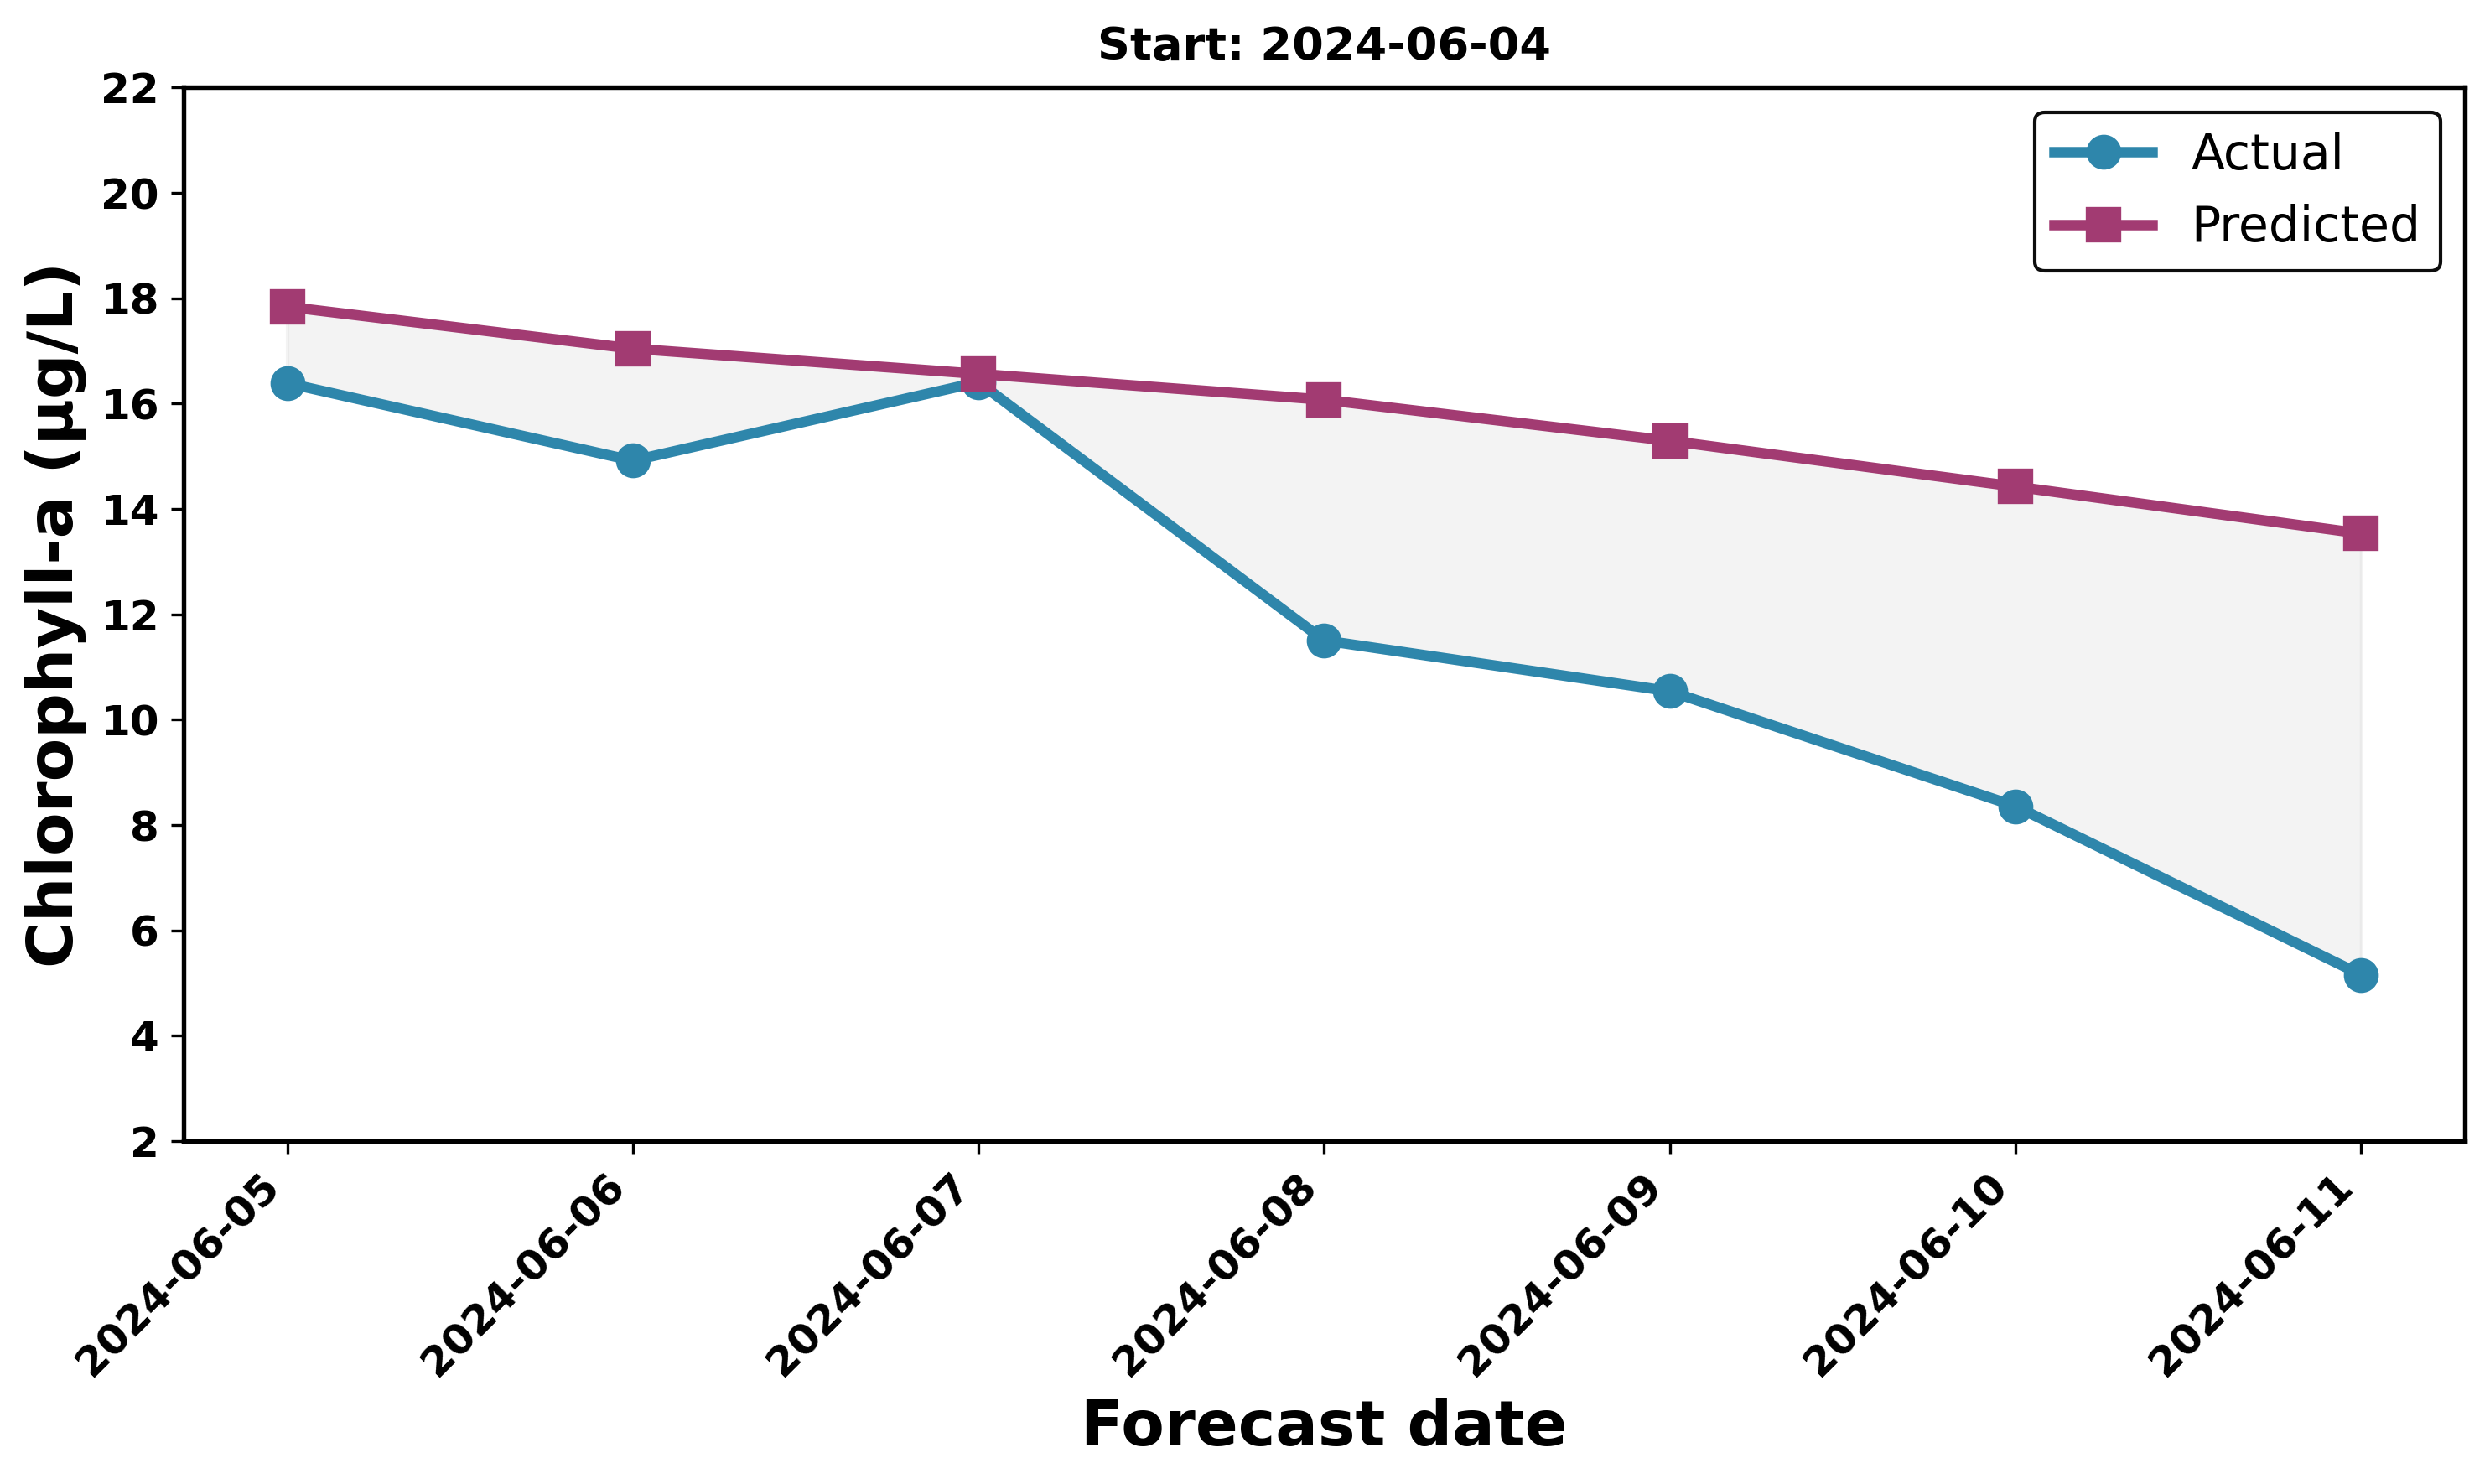

 Saved line plot line_plot_instance1_20240604.png

 Creating waterfall plot...


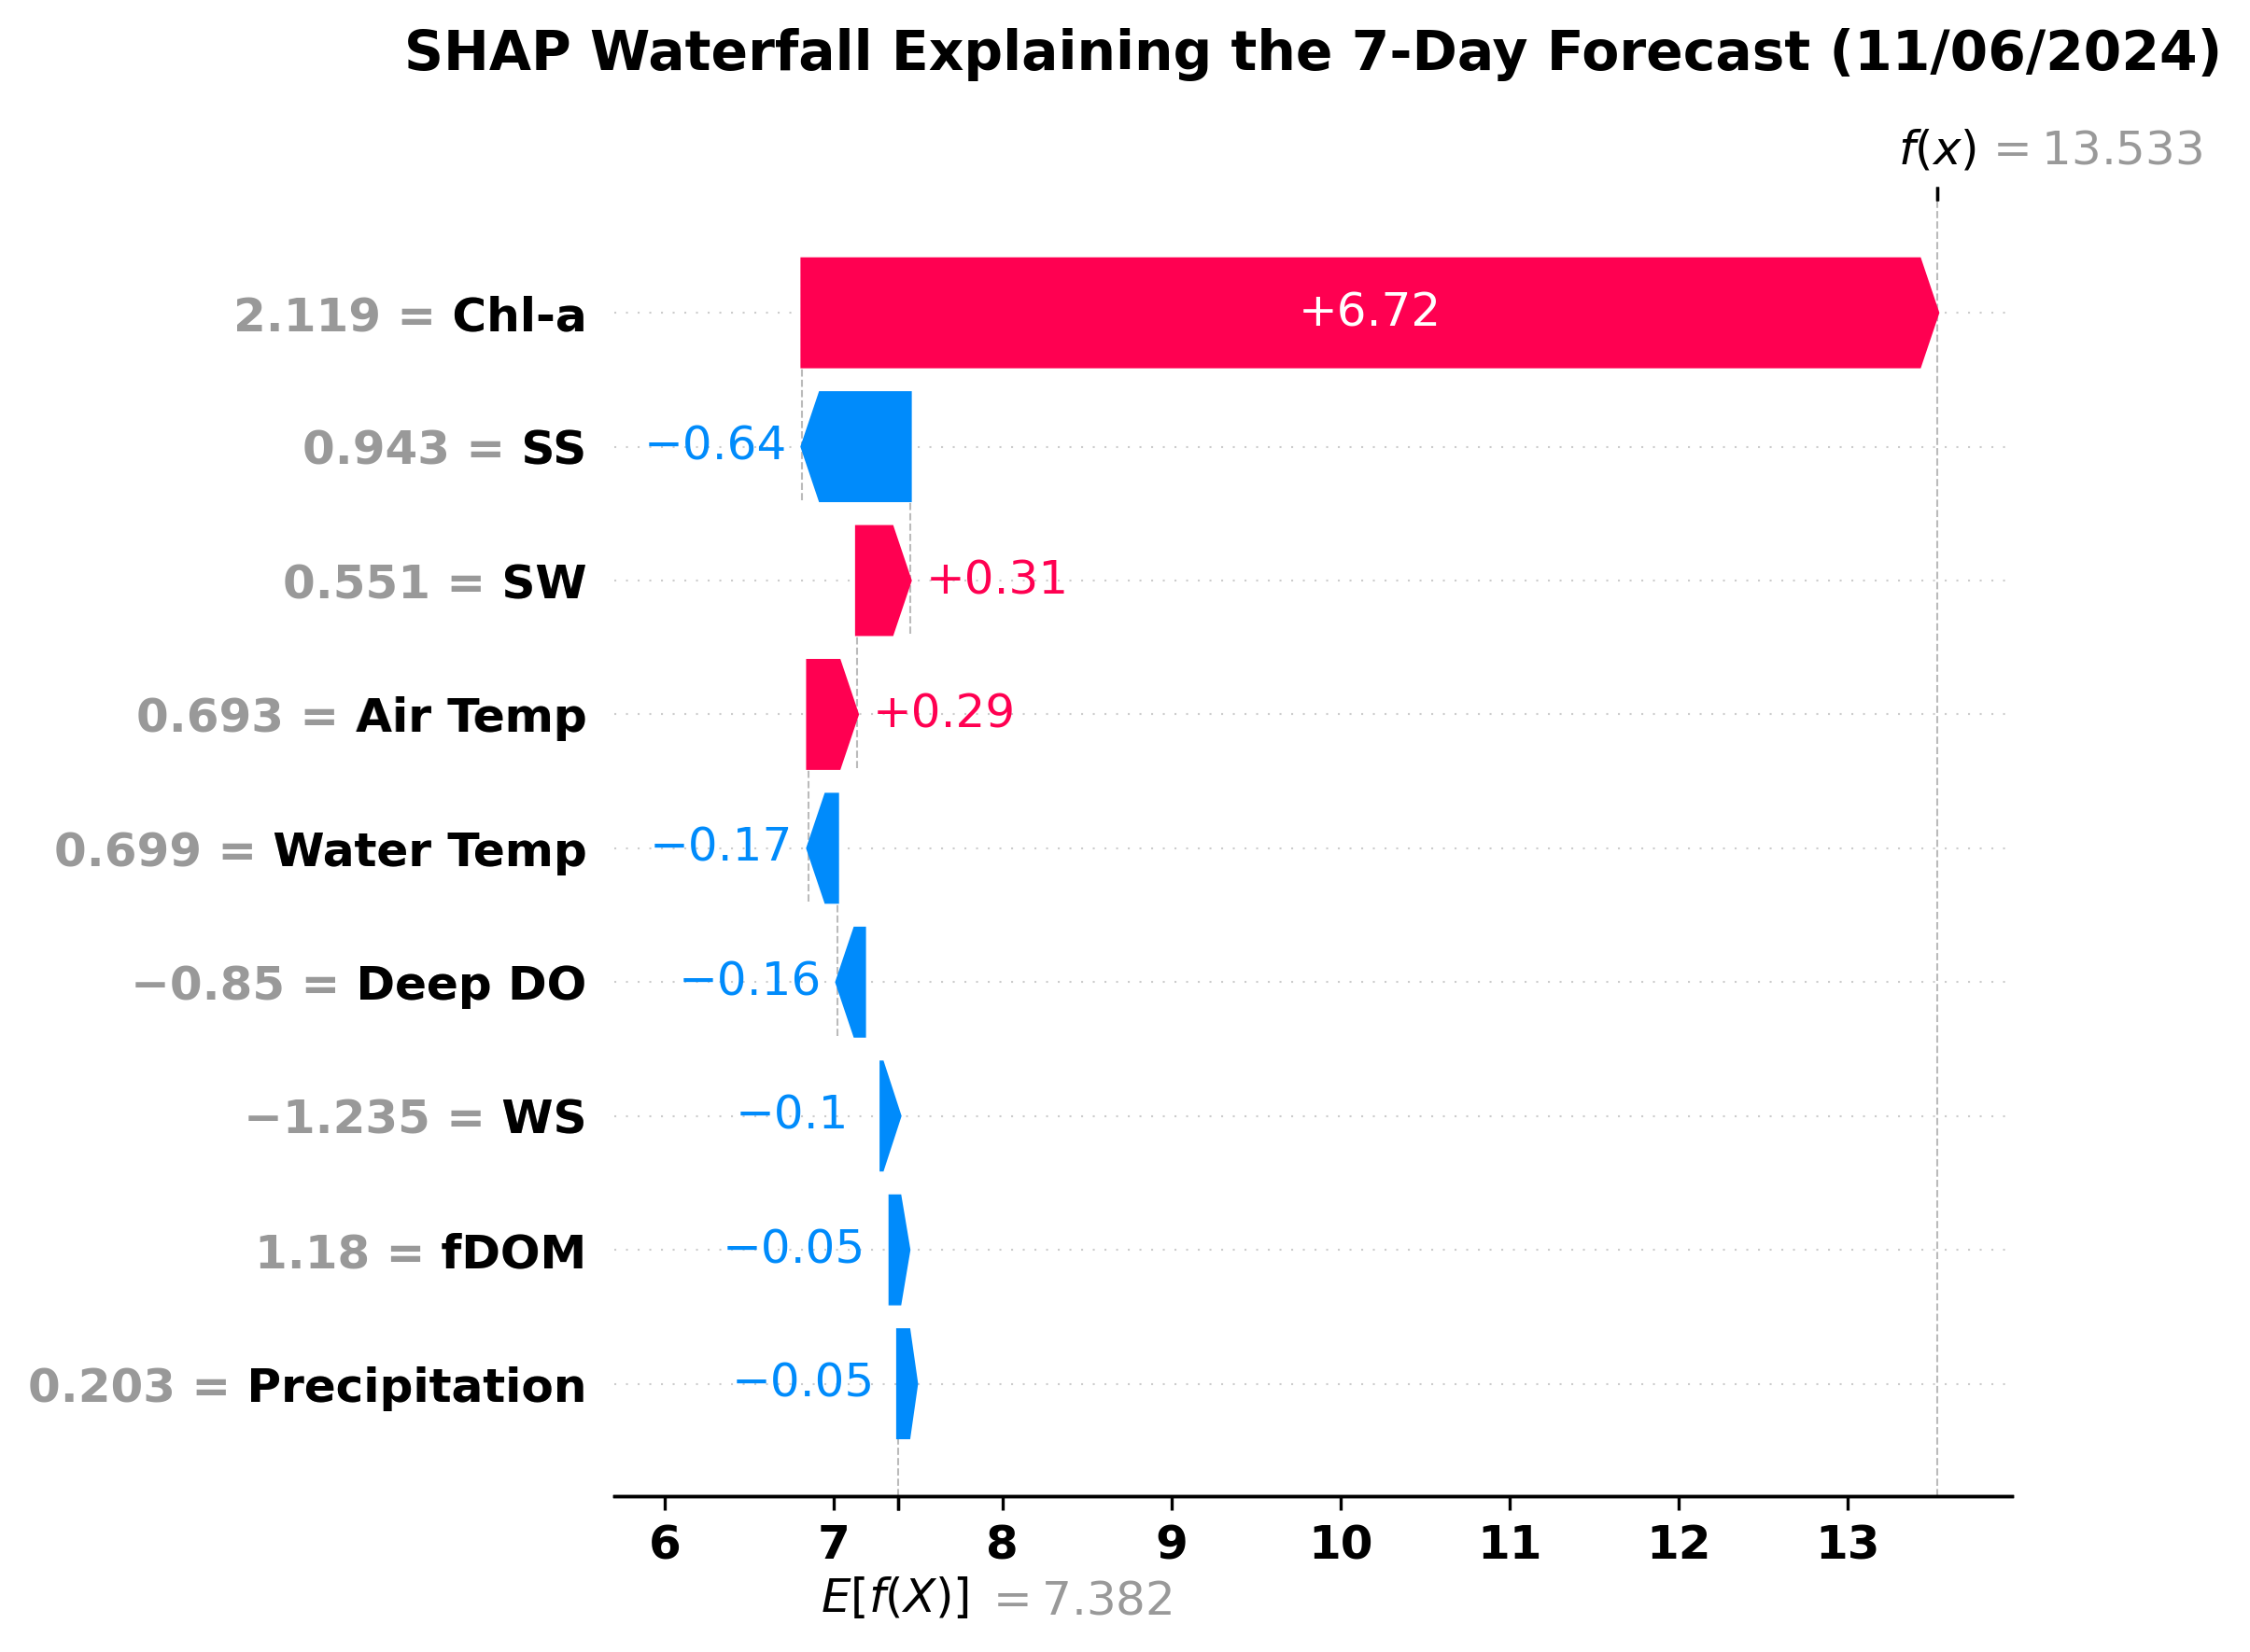

 Saved waterfall plot -> waterfall_instance1_20240604.png

 INSTANCE 2/2: 2024-08-31

 Looking for date: 2024-08-31
 Date: 2024-08-31

 Creating line plot...


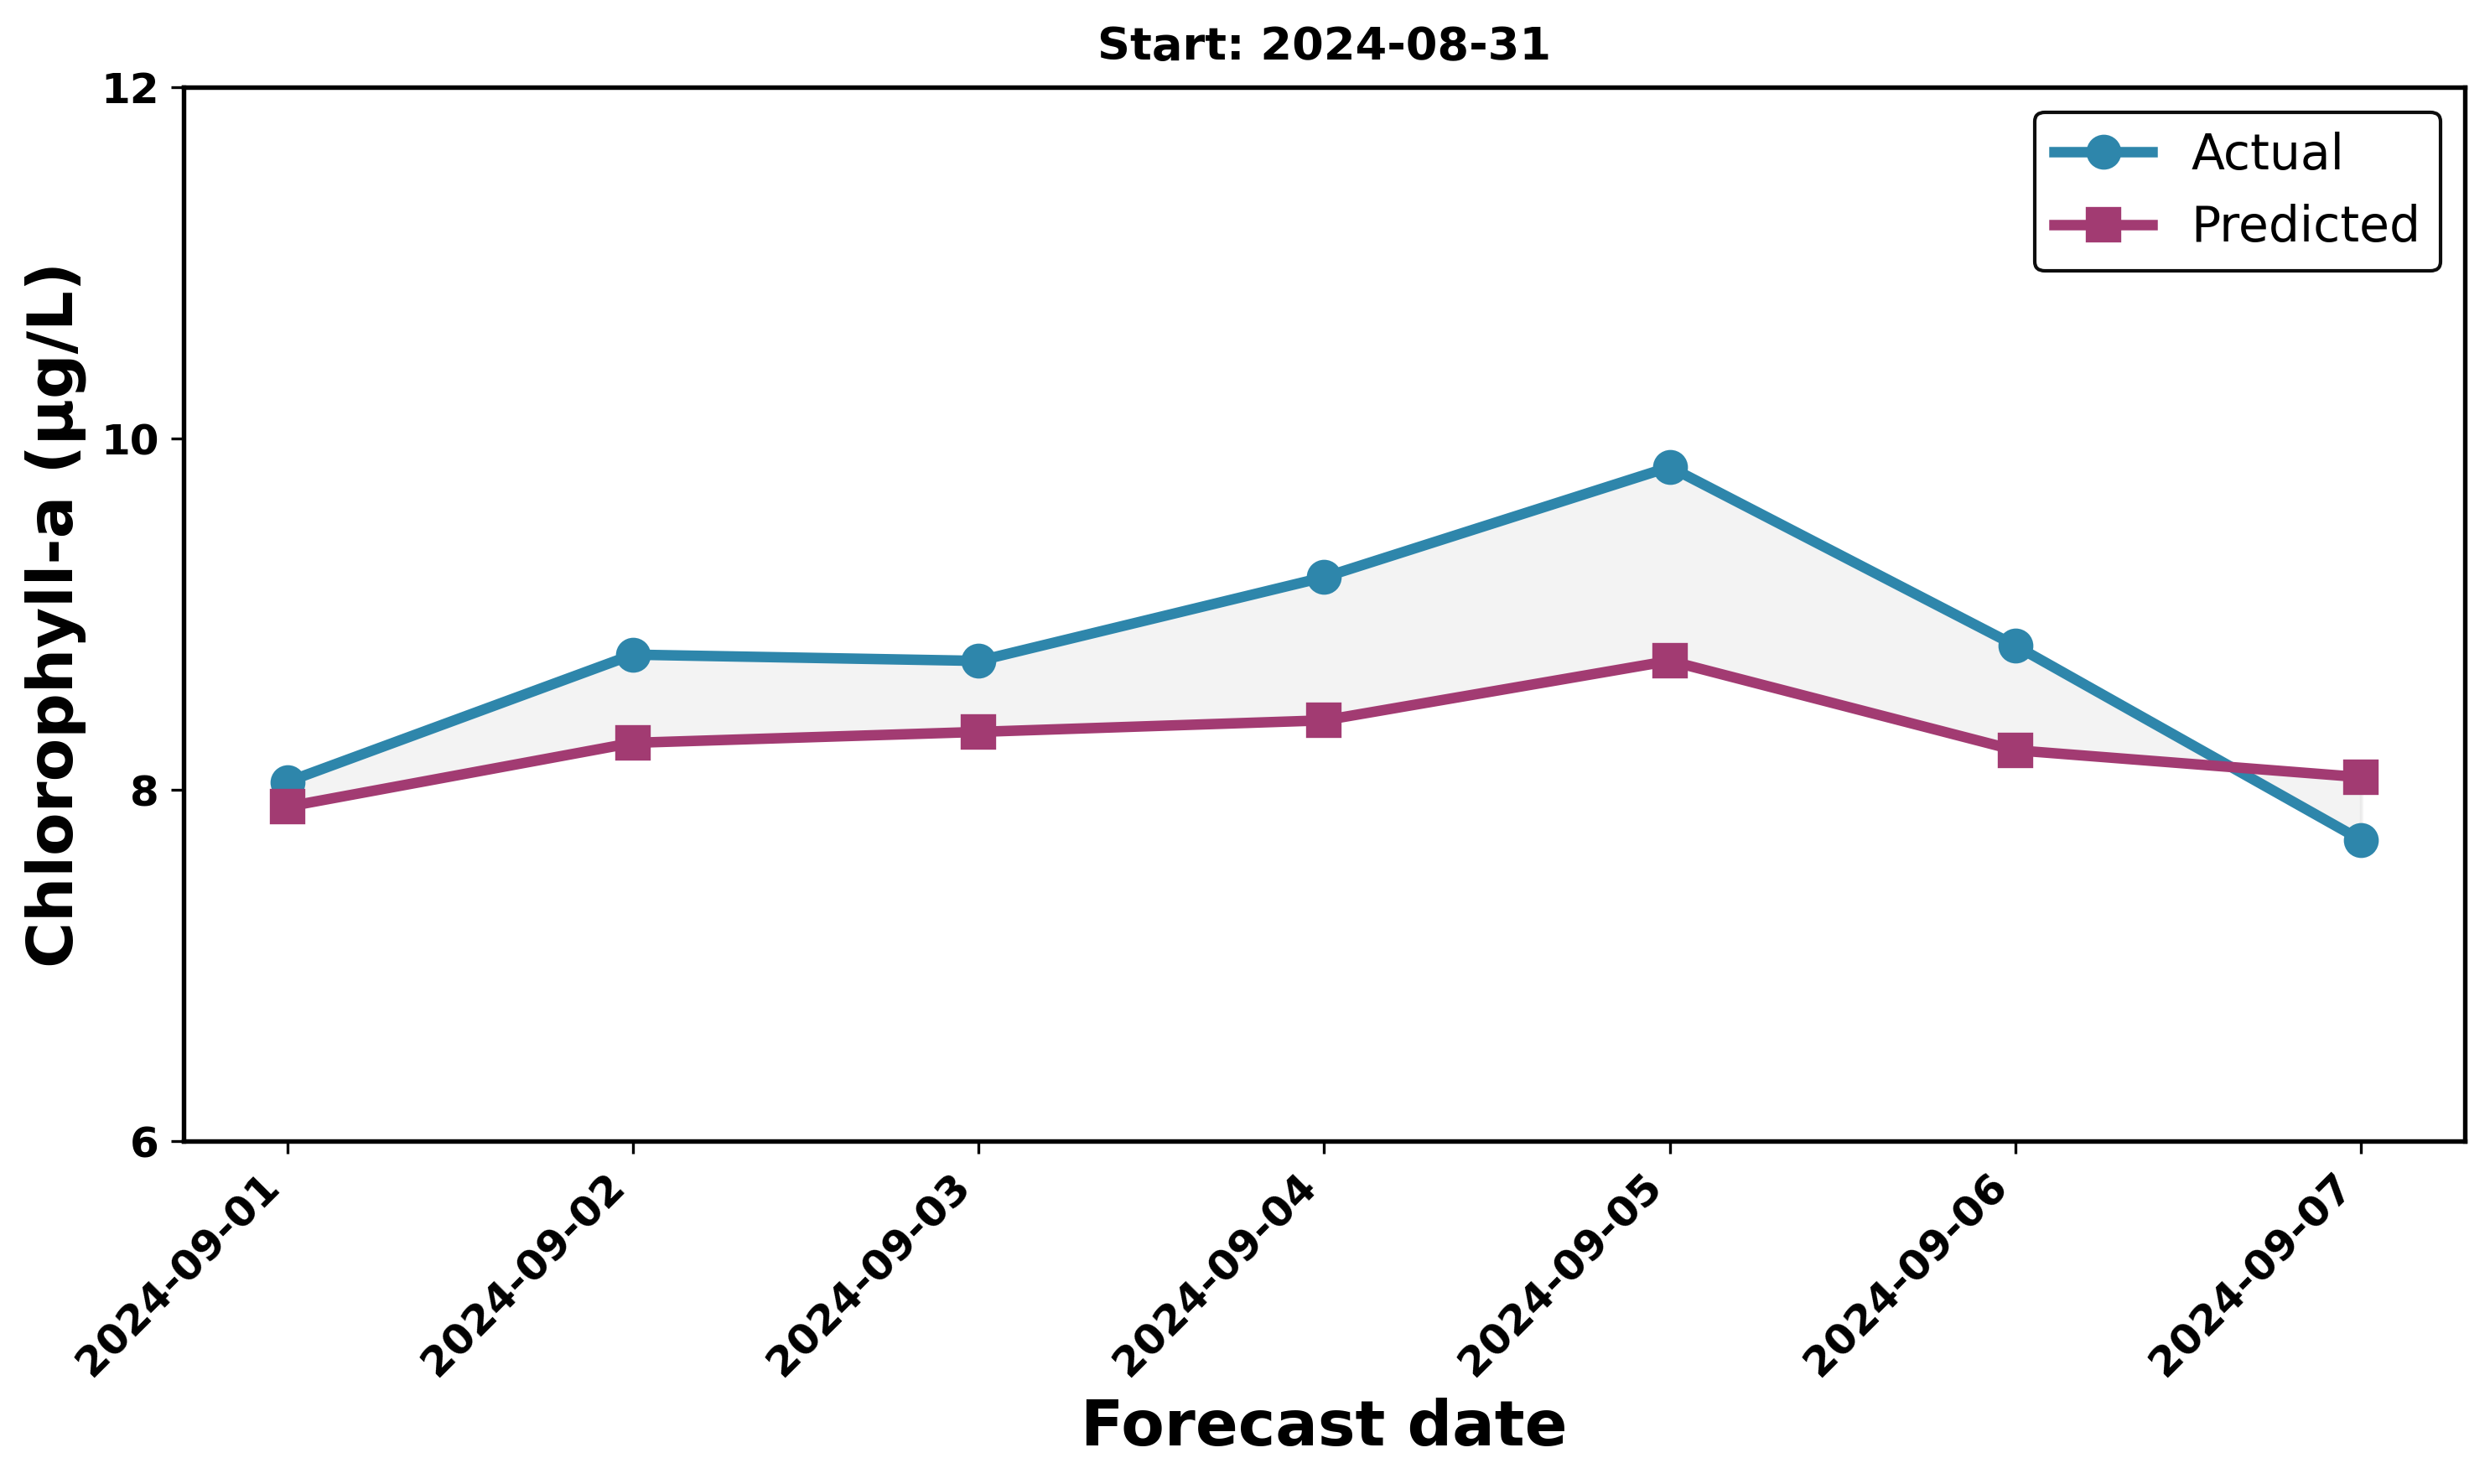

 Saved line plot line_plot_instance2_20240831.png

 Creating waterfall plot...


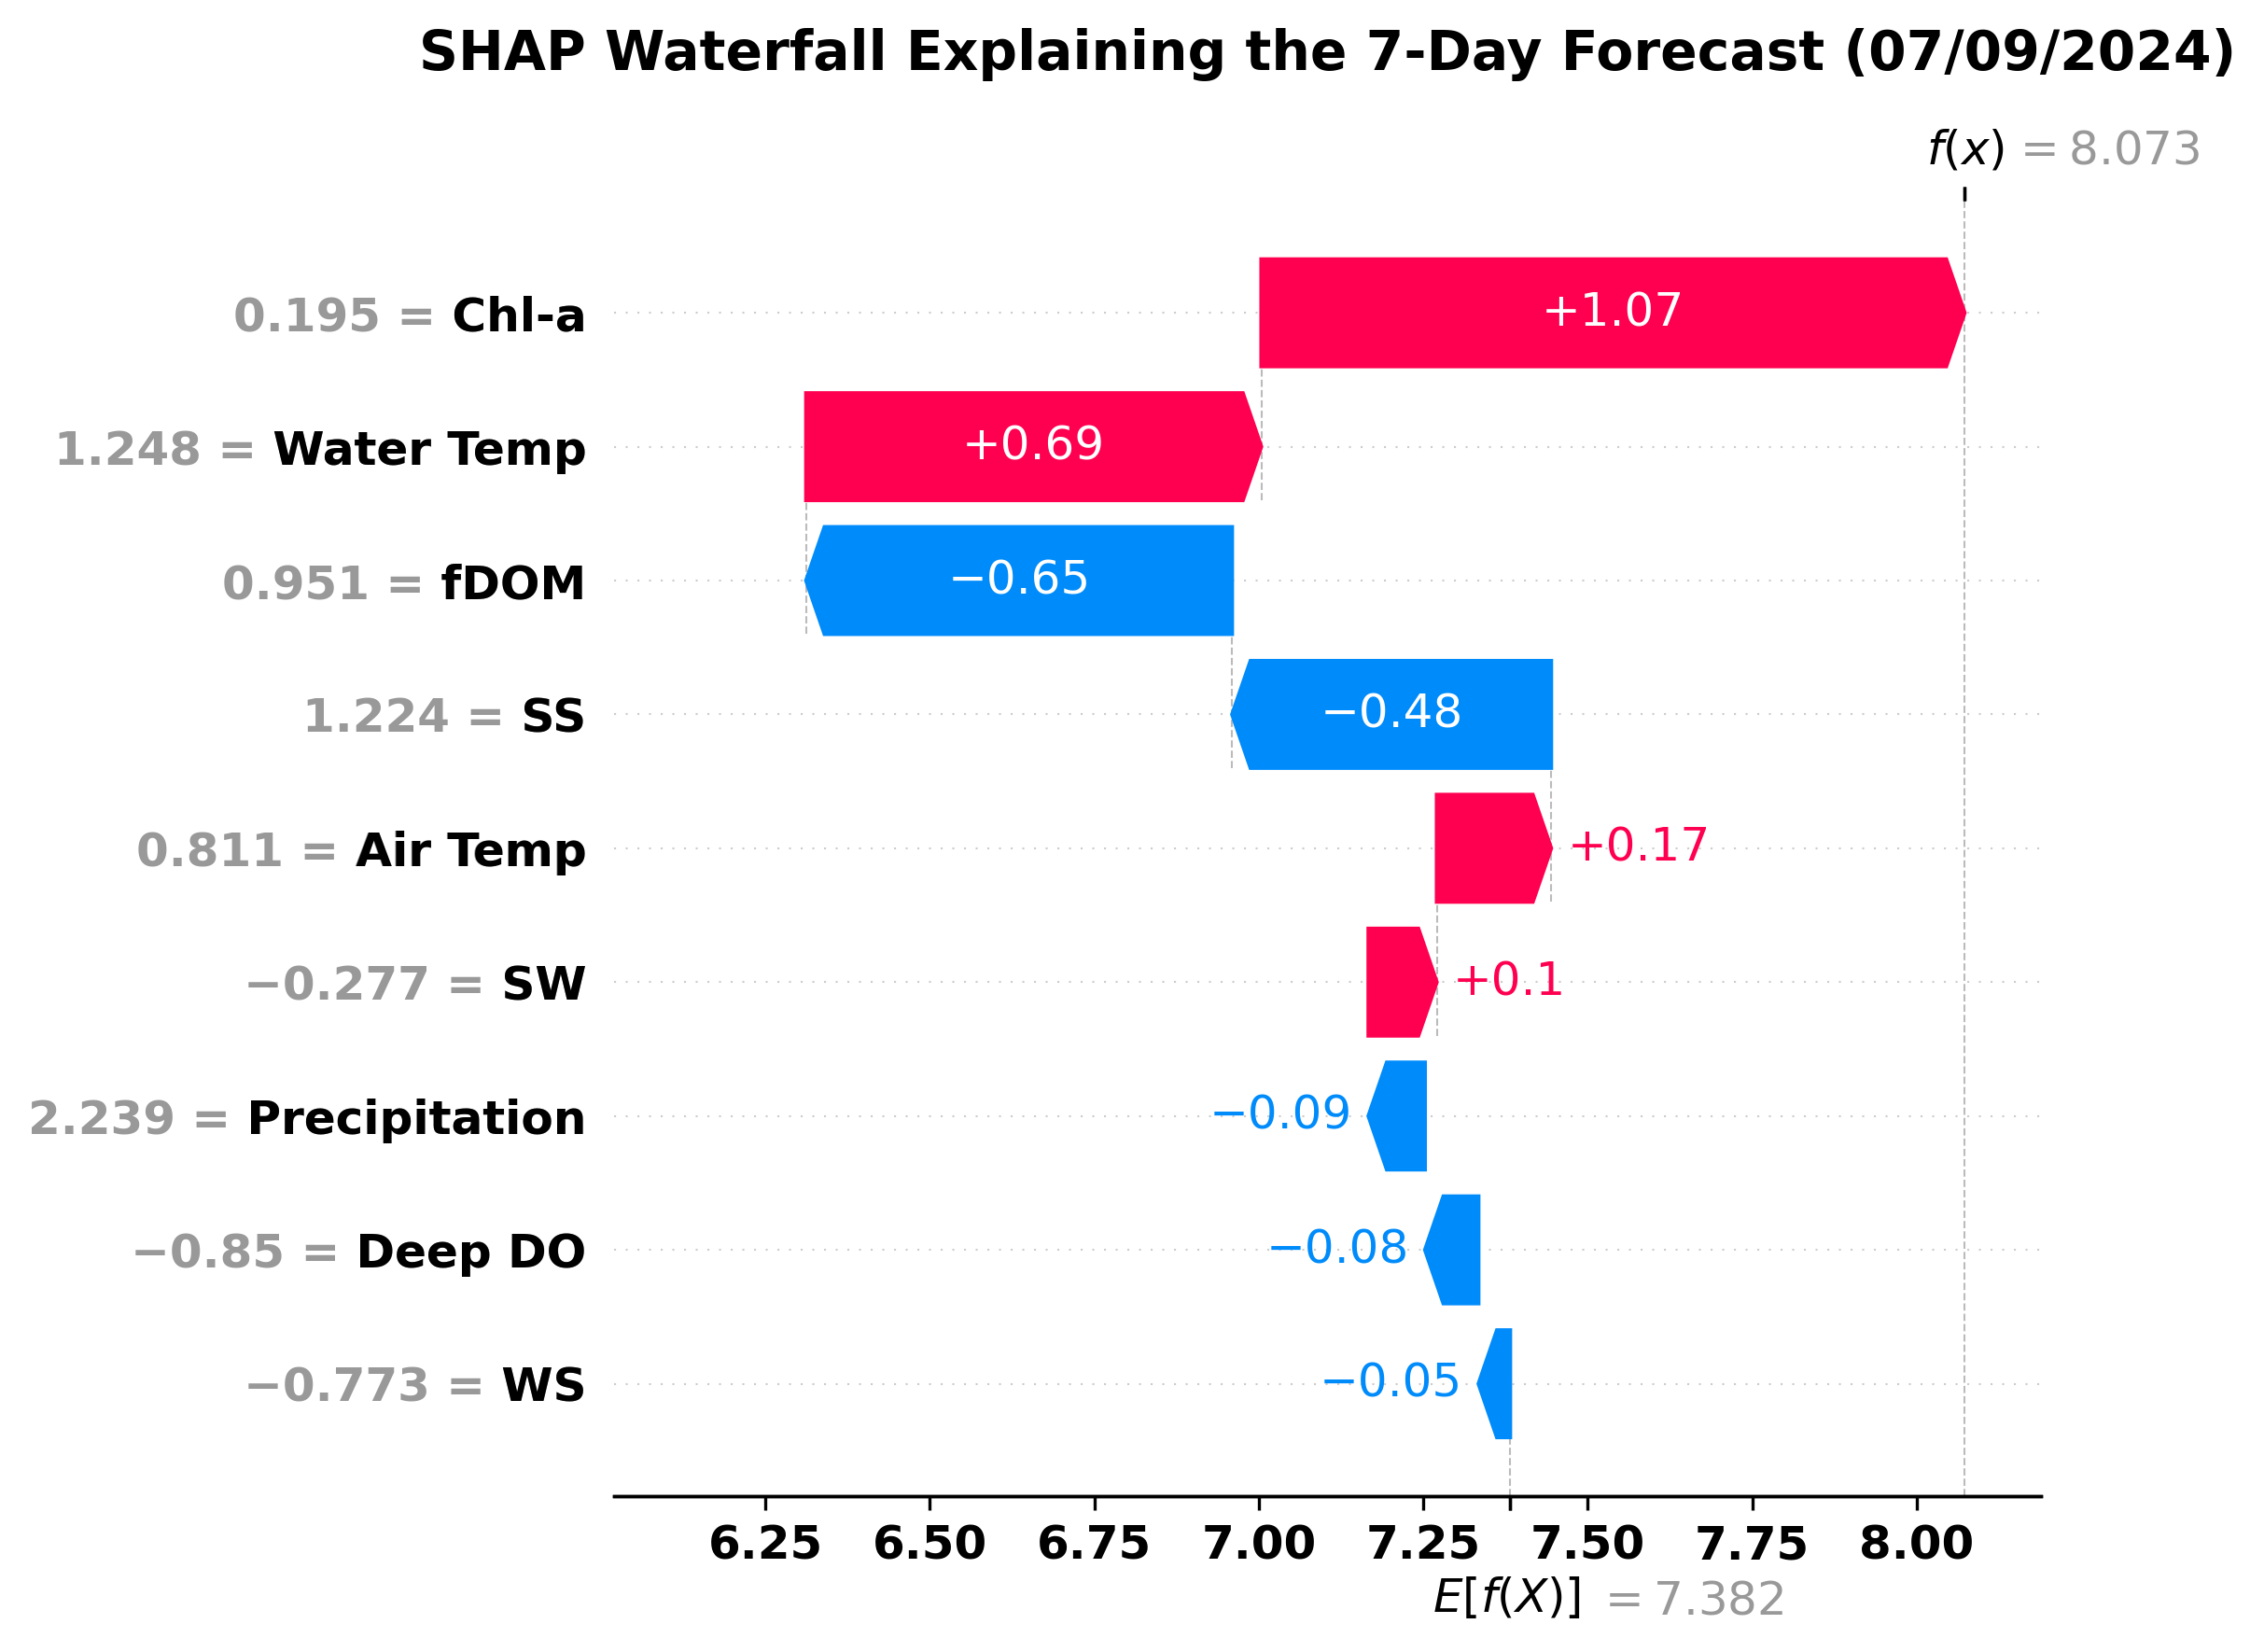

 Saved waterfall plot -> waterfall_instance2_20240831.png
 ALL INSTANCES COMPLETE


In [17]:
# ------------------------------------------------------------
# INSTANCE PLOTS BY DATE (local explanability)
# ------------------------------------------------------------
# PURPOSE:
# 1. Plot line plot + waterfall plot for each specified date
# 2. Two instances: 2024-06-04 and 2024-08-31
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(" CUSTOM INSTANCE PLOTS BY DATE (TWO INSTANCES)")

# ------------------------------------------------------------
# CONFIGURATION: INPUT DATES AND Y-AXIS RANGE (PER INSTANCE)
# ------------------------------------------------------------

INSTANCES = [
    {
        'date': '2024-06-04',
        'y_min': 2.0,
        'y_max': 22.0,
        'tick_interval': 2,
    },
    {
        'date': '2024-08-31',
        'y_min': 6.0,
        'y_max': 12.0,
        'tick_interval': 2,
    },
]

# ------------------------------------------------------------

# Check if variables exist
if 'X_test_processed' not in globals():
    raise ValueError(" Error: X_test_processed not found. Please run previous cells first!")

# Get predictions
if 'y_test_pred' not in globals():
    if 'y_pred_test' in globals():
        y_test_pred = y_pred_test
    else:
        y_test_pred = final_model.predict(X_test_processed)

y_test_pred = np.asarray(y_test_pred)
y_test_arr = np.asarray(y_test)
n_horizons = y_test_pred.shape[1]

# Setup SHAP for waterfall plots
if 'explainer_7d' not in globals():
    try:
        import shap
        model_7d = final_model.estimators_[-1]
        explainer_7d = shap.TreeExplainer(model_7d)
    except ImportError:
        import subprocess
        subprocess.check_call(["pip", "install", "-q", "shap"])
        import shap
        model_7d = final_model.estimators_[-1]
        explainer_7d = shap.TreeExplainer(model_7d)

# Feature abbreviation map
if 'FEATURE_ABBREV_MAP' not in globals():
    FEATURE_ABBREV_MAP = {
        'BVR_mean_EXOChla_ugL_1.5': 'Chl-a',
        'BVR_mean_EXOfDOM_QSU_1.5': 'fDOM',
        'BVR_mean_EXOTemp_C_1.5': 'Water Temp',
        'BVR_mean_schmidt_stability': 'SS',
        'BVR_mean_RDOsat_percent_13': 'Deep DO',
        'mean_ShortwaveRadiationUp_Average_W_m2': 'SR',
        'mean_AirTemp_C_Average': 'AT',
        'mean_WindSpeed_Average_m_s': 'WS',
        'sum_Rain_Total_mm': 'Rain'
    }

COLOR_ACTUAL = '#2E86AB'
COLOR_PRED = '#A23B72'
COLOR_FILL = '#D1D1D1'

h = np.arange(1, n_horizons + 1)
test_dates = pd.to_datetime(X_test_processed.index)

# ============================================================
# LOOP OVER EACH INSTANCE DATE
# ============================================================

for instance_num, inst_cfg in enumerate(INSTANCES, 1):

    START_DATE = inst_cfg['date']
    Y_AXIS_MIN = inst_cfg['y_min']
    Y_AXIS_MAX = inst_cfg['y_max']
    Y_AXIS_TICK_INTERVAL = inst_cfg['tick_interval']

    print(f"\n{'=' * 60}")
    print(f" INSTANCE {instance_num}/{len(INSTANCES)}: {START_DATE}")
    print(f"{'=' * 60}")

    # Convert date to datetime
    try:
        if '/' in START_DATE:
            target_date = pd.to_datetime(START_DATE, format='%d/%m/%Y')
        else:
            target_date = pd.to_datetime(START_DATE)
    except:
        raise ValueError(f" Error: Invalid date format for '{START_DATE}'. Use 'YYYY-MM-DD' or 'DD/MM/YYYY'")

    print(f"\n Looking for date: {target_date.date()}")

    # Find date in test data
    date_idx = None
    for idx, date in enumerate(test_dates):
        if date.date() == target_date.date():
            date_idx = idx
            break

    if date_idx is None:
        print(f" WARNING: Date {target_date.date()} not found in test data. Skipping...")
        continue

    #print(f" Found at index {date_idx}")

    # Get data for this date
    start_date = test_dates[date_idx]
    actuals = y_test_arr[date_idx, :]
    preds = y_test_pred[date_idx, :]
    orig_idx = date_idx

    print(f" Date: {start_date.date()}")
    if 'errors_per_sample' in globals():
        print(f" Mean Error: {errors_per_sample[orig_idx].mean():.3f} µg/L")

    # Calculate y-axis range
    if Y_AXIS_MIN is not None and Y_AXIS_MAX is not None:
        y_low = Y_AXIS_MIN
        y_high = Y_AXIS_MAX
        #print(f"\n Using manual y-axis range: [{y_low:.2f}, {y_high:.2f}]")
    else:
        y_min = min(actuals.min(), preds.min())
        y_max = max(actuals.max(), preds.max())
        y_rng = y_max - y_min if y_max > y_min else 1
        y_low = max(0.0, y_min - 0.2 * y_rng)
        y_high = y_max + 0.5 * y_rng
        #print(f"\n Auto y-axis range: [{y_low:.2f}, {y_high:.2f}]")

    # Calculate y-axis ticks if interval is specified
    if Y_AXIS_TICK_INTERVAL is not None:
        y_ticks = np.arange(y_low, y_high + Y_AXIS_TICK_INTERVAL, Y_AXIS_TICK_INTERVAL)
        y_ticks = y_ticks[(y_ticks >= y_low) & (y_ticks <= y_high)]
        #print(f" Y-axis tick interval: {Y_AXIS_TICK_INTERVAL} (ticks: {len(y_ticks)} points)")
    else:
        y_ticks = None
        #print(f" Using automatic y-axis ticks")

    # ------------------------------------------------------------
    # LINE PLOT
    # ------------------------------------------------------------

    print("\n Creating line plot...")

    x_dates = start_date + pd.to_timedelta(h, unit="D")

    fig_line = plt.figure(figsize=(10, 6), dpi=300)
    ax = plt.gca()

    # Plot actual
    ax.plot(
        x_dates, actuals,
        color=COLOR_ACTUAL, linewidth=3,
        marker='o', markersize=8,
        markerfacecolor='#2E86AB', markeredgecolor='#2E86AB', markeredgewidth=2,
        label='Actual'
    )

    # Plot predicted
    ax.plot(
        x_dates, preds,
        color=COLOR_PRED, linewidth=3,
        marker='s', markersize=8,
        markerfacecolor='#A23B72', markeredgecolor='#A23B72', markeredgewidth=2,
        label='Predicted'
    )

    # Fill between
    ax.fill_between(x_dates, actuals, preds, color=COLOR_FILL, alpha=0.25)

    # Title
    ax.set_title(
        f'Start: {start_date.date()}',
        fontsize=13, fontweight='bold', pad=8
    )

    # Y-limits
    ax.set_ylim(y_low, y_high)

    # Set y-axis ticks if interval is specified
    if y_ticks is not None:
        ax.set_yticks(y_ticks)

    ax.grid(False)

    # Make full box visible
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.3)

    # X-axis
    ax.set_xticks(x_dates)
    ax.set_xticklabels(
        [d.strftime('%Y-%m-%d') for d in x_dates],
        rotation=45, ha='right', fontsize=12, fontweight='bold'
    )

    # Labels
    ax.set_xlabel("Forecast date", fontsize=18, fontweight='bold')
    ax.set_ylabel("Chlorophyll-a (µg/L)", fontsize=18, fontweight='bold')

    custom_size = 12
    for lab in ax.get_yticklabels():
        lab.set_fontweight('bold')
        lab.set_fontsize(custom_size)

    # Legend
    ax.legend(
        ['Actual', 'Predicted'],
        loc='upper right',
        frameon=True,
        fontsize=14,
        framealpha=0.95,
        edgecolor='black'
    )

    plt.tight_layout()
    plt.grid(False)

    # Save
    save_path_line = f"line_plot_instance{instance_num}_{start_date.strftime('%Y%m%d')}.png"
    plt.savefig(save_path_line, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f" Saved line plot {save_path_line}")

    # ------------------------------------------------------------
    # WATERFALL PLOT
    # ------------------------------------------------------------

    print("\n Creating waterfall plot...")

    # Get input features
    x_input = X_test_processed.iloc[[date_idx]]

    # Get 7-day prediction and actual
    y_pred_7d = y_test_pred[orig_idx, -1]
    y_true_7d = y_test_arr[orig_idx, -1]
    error_7d = abs(y_pred_7d - y_true_7d)

    # Compute SHAP values
    shap_values = explainer_7d.shap_values(x_input, check_additivity=False)[0]
    base_value = explainer_7d.expected_value

    # Create SHAP Explanation
    shap_exp = shap.Explanation(
        values=shap_values,
        base_values=base_value,
        data=x_input.iloc[0].values,
        feature_names=[FEATURE_ABBREV_MAP.get(f, f) for f in x_input.columns]
    )

    # Create waterfall plot
    fig_waterfall = plt.figure(figsize=(10, 8), dpi=300)
    ax = plt.gca()

    shap.plots.waterfall(shap_exp, max_display=10, show=False)

    # Title using END DATE
    end_date = start_date + pd.Timedelta(days=7)

    ax.set_title(
        f"SHAP Waterfall Explaining the 7-Day Forecast ({end_date.strftime('%d/%m/%Y')})",
        fontsize=14,
        fontweight='bold',
        pad=15
    )

    # Adjust layout
    ax.tick_params(labelsize=12)
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')

    # Y-tick labels bold + custom size
    ytick_size = 12
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(ytick_size)

    plt.tight_layout()

    # Save
    save_path_waterfall = f"waterfall_instance{instance_num}_{start_date.strftime('%Y%m%d')}.png"
    plt.savefig(save_path_waterfall, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f" Saved waterfall plot -> {save_path_waterfall}")


print(" ALL INSTANCES COMPLETE")


 UNCERTAINTY QUANTIFICATION: BOOTSTRAP ENSEMBLE UNCERTAINTY

 Methods:
 1. Bootstrap Ensemble (B=1, 2, 3, 5, 7, 10)

 Evaluation: CRPS (Continuous Ranked Probability Score)
 Helper functions defined (CRPS calculations)

 Configuration:
 Bootstrap sizes: [1, 2, 3, 5, 7, 10]
 Forecast horizons: 7
 Random seed: 42
BOOTSTRAP ENSEMBLE

 Using Existing Single XGBoost Model...
 CRPS (mean): 2.3171

 Bootstrap Ensemble (B=2)...
 2/2 models trained...
 CRPS (mean): 2.1910

 Bootstrap Ensemble (B=3)...
 3/3 models trained...
 CRPS (mean): 2.1368

 Bootstrap Ensemble (B=5)...
 5/5 models trained...
 CRPS (mean): 2.0772

 Bootstrap Ensemble (B=7)...
 5/7 models trained...
 7/7 models trained...
 CRPS (mean): 2.0556

 Bootstrap Ensemble (B=10)...
 5/10 models trained...
 10/10 models trained...
 CRPS (mean): 2.0673

 Bootstrap ensemble analysis complete
 GENERATING COMPARISON FIGURE


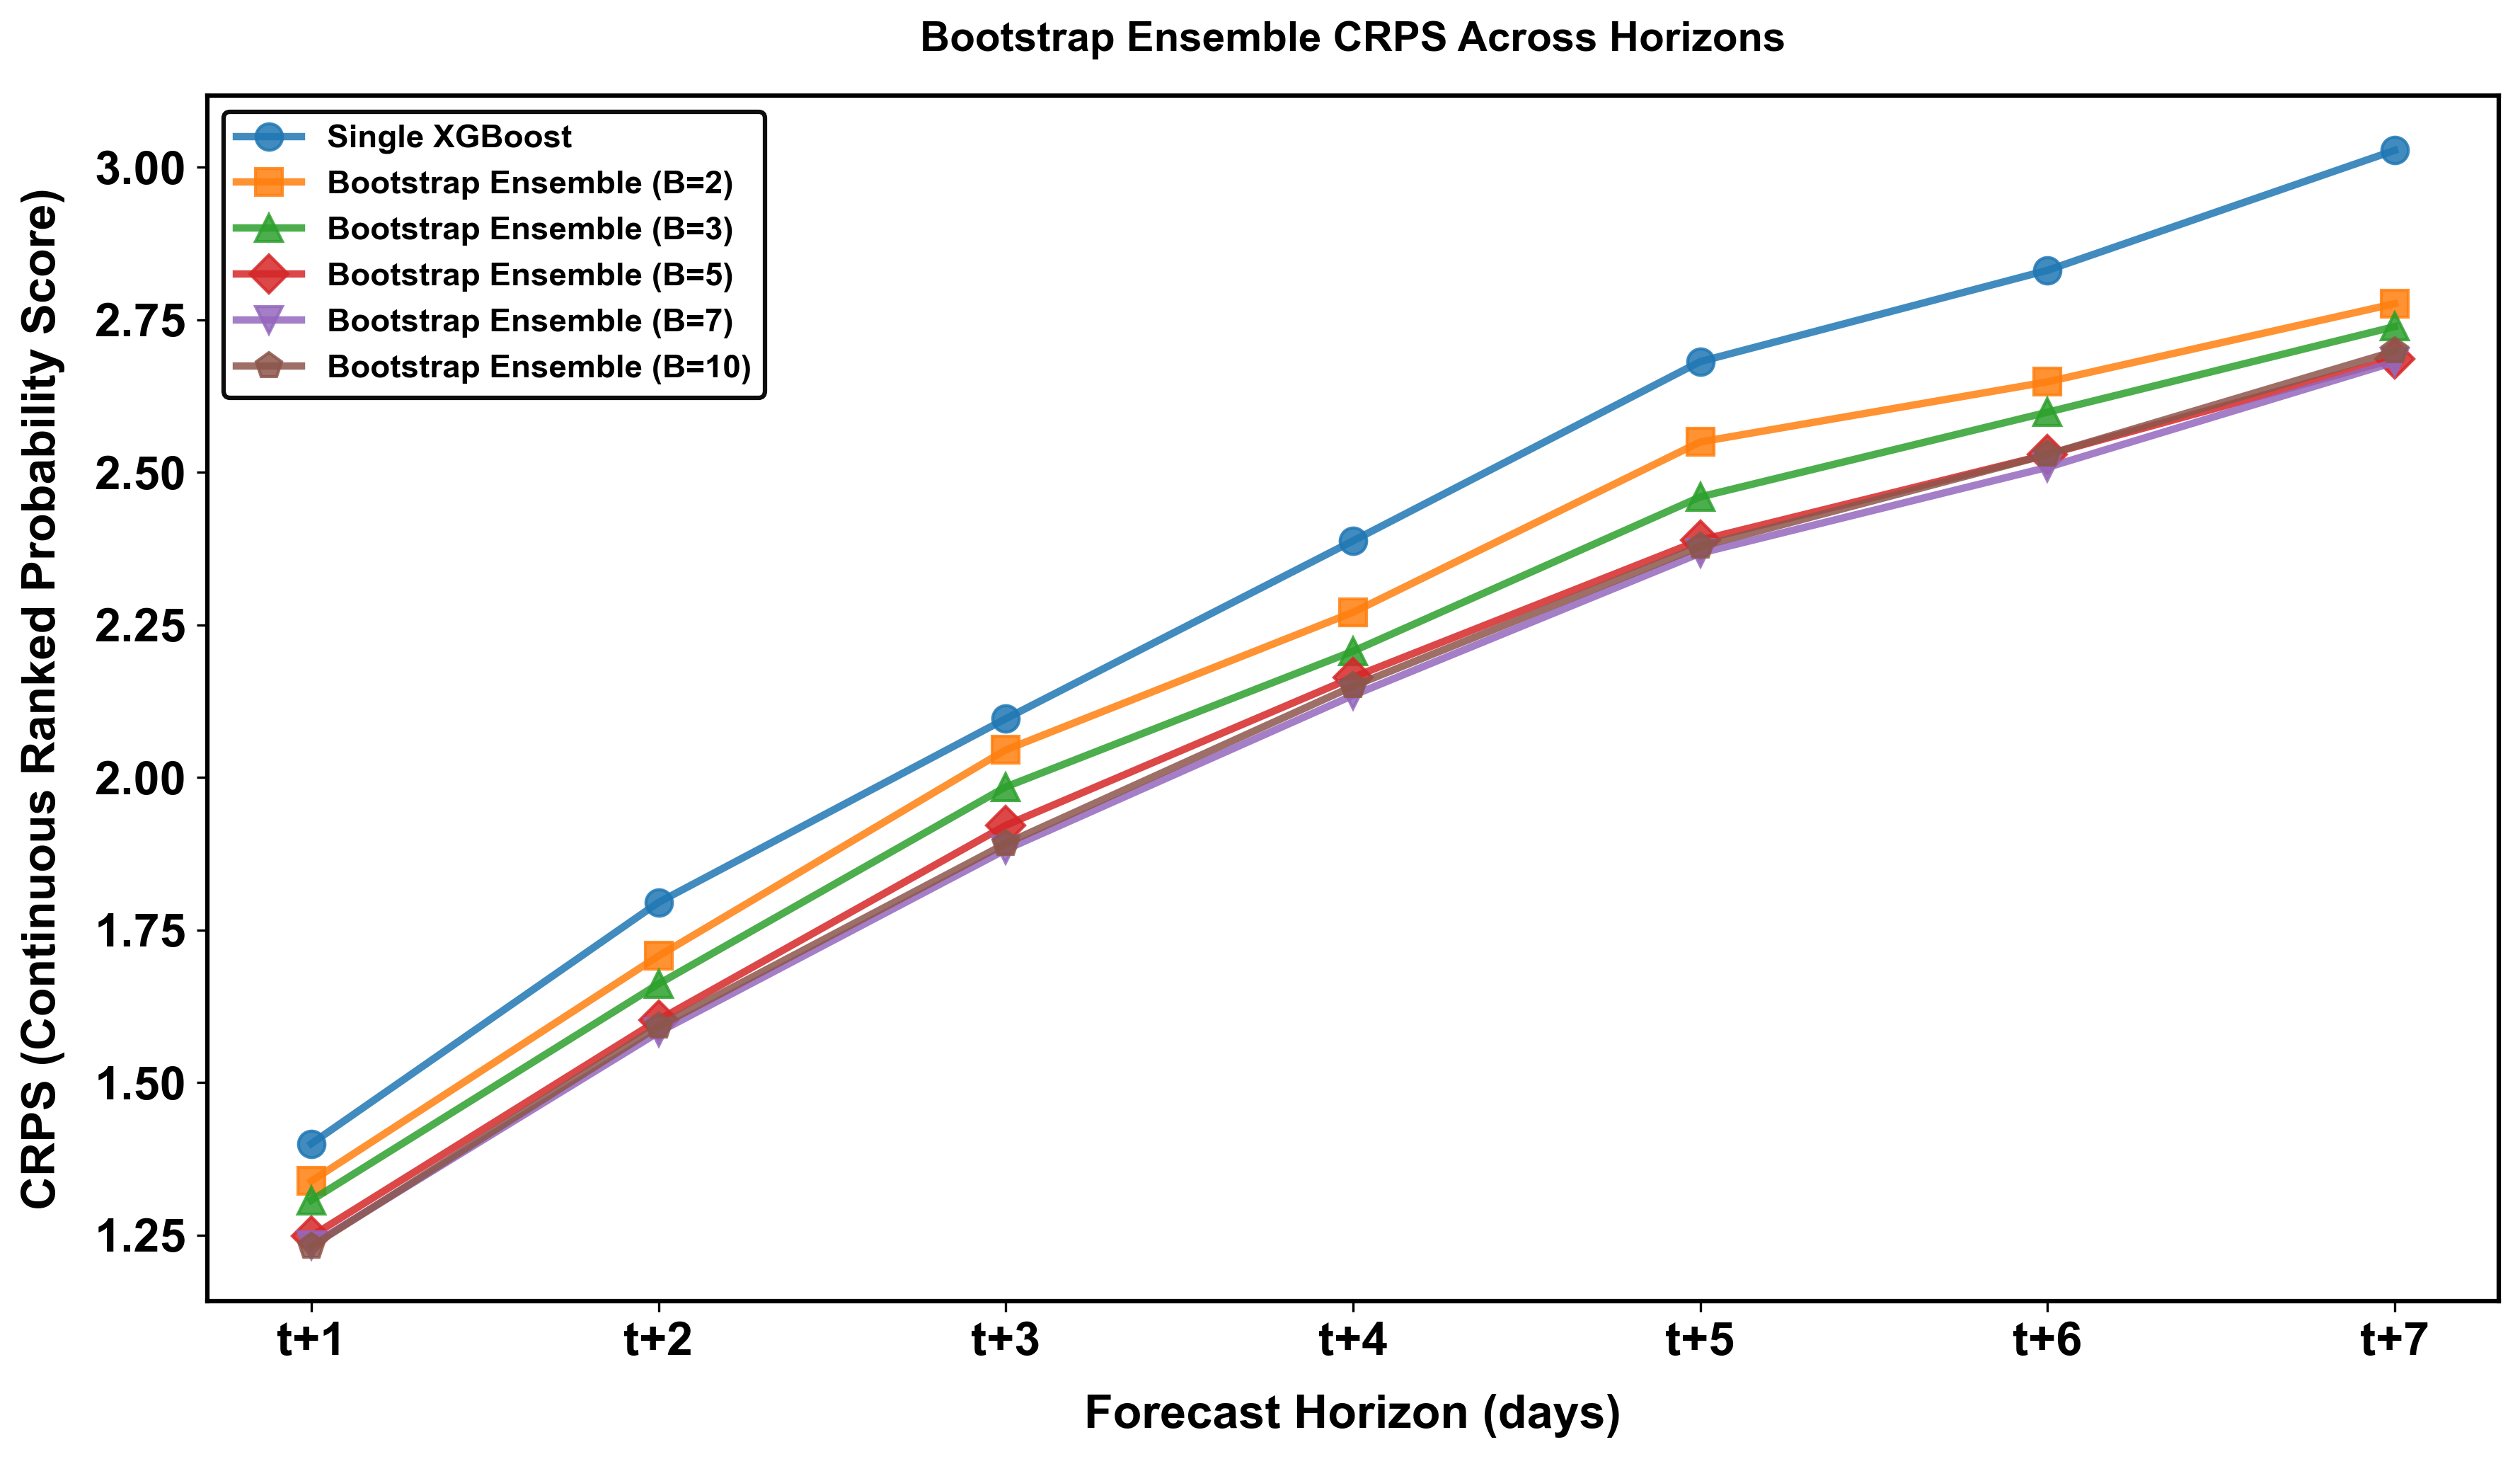

 Saved: ./BVR_Forecasting_Results/uq_bootstrap_ensemble_crps.png

 Generating statistical comparison table...

 Saved: ./BVR_Forecasting_Results/uq_bootstrap_ensemble_crps_table.csv

 FILES GENERATED:
 1. uq_bootstrap_ensemble_crps.png
 2. uq_bootstrap_ensemble_crps_table.csv
 UNCERTAINTY QUANTIFICATION ANALYSIS COMPLETE


In [19]:
# ------------------------------------------------------------
# CUNCERTAINTY QUANTIFICATION - BOOTSTRAP ENSEMBLE UNCERTAINTY
# ------------------------------------------------------------
# PURPOSE: Uncertainty evaluation using CRPS
# Bootstrap Ensemble - Epistemic uncertainty via data resampling (B=1,2,3,5,7,10)
# ------------------------------------------------------------

print(" UNCERTAINTY QUANTIFICATION: BOOTSTRAP ENSEMBLE UNCERTAINTY")
print("\n Methods:")
print(" 1. Bootstrap Ensemble (B=1, 2, 3, 5, 7, 10)")
print("\n Evaluation: CRPS (Continuous Ranked Probability Score)")

from sklearn.utils import resample
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor

# ============================================================================
# Helper Functions (CRPS Calculations)
# ============================================================================

def crps_ensemble_vec(preds_2d, obs_1d):
    """
    Vectorized CRPS for ensemble predictions.

    CRPS = E[|X - y|] - 0.5 * E[|X - X'|]

    This is the standard ensemble CRPS formula for probabilistic forecasts.

    Reference: Hersbach (2000) - "Decomposition of the CRPS"

    Parameters:
    -----------
    preds_2d : array (N, B) - Ensemble predictions (N samples, B ensemble members)
    obs_1d : array (N,) - Observed values

    Returns:
    --------
    array (N,) - CRPS per sample
    """
    P = np.asarray(preds_2d) # (N, B)
    y = np.asarray(obs_1d) # (N,)


    term1 = np.mean(np.abs(P - y[:, None]), axis=1)
    diffs = np.abs(P[:, :, None] - P[:, None, :])
    term2 = np.mean(diffs, axis=(1, 2))

    return term1 - 0.5 * term2

print(" Helper functions defined (CRPS calculations)")

# ============================================================================
# Configuration
# ============================================================================

# Bootstrap ensemble sizes
B_LIST = [1, 2, 3, 5, 7, 10]


SEED = 42

print(f"\n Configuration:")
print(f" Bootstrap sizes: {B_LIST}")
print(f" Forecast horizons: {FORECAST_HORIZONS}")
print(f" Random seed: {SEED}")

# Storage for results
crps_dict = {}
crps_samples_dict = {}

N_test = len(X_test_processed)

# ============================================================================
# BOOTSTRAP ENSEMBLE
# ============================================================================

print("BOOTSTRAP ENSEMBLE")

for B in B_LIST:
    if B == 1:
        print(f"\n Using Existing Single XGBoost Model...")
        model_single = None
        model_name = None

        try:
            model_single = final_model
            model_name = 'final_model'
        except NameError:
            try:
                model_single = final_estimator
                model_name = 'final_estimator'
            except NameError:
                try:
                    model_single = final_xgboost
                    model_name = 'final_xgboost'
                except NameError:
                    raise NameError(
                        "\n ERROR: No existing trained model found!\n"
                        " B=1 is the XGBoost model used above.\n"
                        " - 'final_model'\n"
                        " - 'final_estimator'\n"
                        " - 'final_xgboost'\n"
                    )

        # Use existing model
        all_preds = np.zeros((N_test, FORECAST_HORIZONS, 1), dtype=np.float32)
        all_preds[:, :, 0] = model_single.predict(X_test_processed)

    else:
        print(f"\n Bootstrap Ensemble (B={B})...")

        all_preds = np.zeros((N_test, FORECAST_HORIZONS, B), dtype=np.float32)

        for b in range(B):
            # Resample training data with replacement
            X_boot, y_boot = resample(
                X_train_processed, y_train,
                replace=True, random_state=SEED + b
            )

            # Train model on resampled data
            model_boot = MultiOutputRegressor(
                xgb.XGBRegressor(**best_params, random_state=SEED + b, n_jobs=1)
            )
            model_boot.fit(X_boot, y_boot)
            all_preds[:, :, b] = model_boot.predict(X_test_processed)

            if (b + 1) % 5 == 0 or (b + 1) == B:
                print(f" {b+1}/{B} models trained...")

    # Compute CRPS for this bootstrap size
    crps_b = []
    crps_b_per_sample = np.zeros((N_test, FORECAST_HORIZONS), dtype=np.float32)

    for h in range(FORECAST_HORIZONS):
        # For B=1, CRPS reduces to MAE (single prediction)
        if B == 1:
            vals = np.abs(all_preds[:, h, 0] - y_test.iloc[:, h].values)
        else:
            vals = crps_ensemble_vec(all_preds[:, h, :], y_test.iloc[:, h].values)

        crps_b.append(float(vals.mean()))
        crps_b_per_sample[:, h] = vals

    # Label: B=1 is "Single XGBoost", B>1 is "Bootstrap Ensemble (B=X)"
    if B == 1:
        label = "Single XGBoost"
    else:
        label = f"Bootstrap Ensemble (B={B})"

    crps_dict[label] = crps_b
    crps_samples_dict[label] = crps_b_per_sample

    print(f" CRPS (mean): {np.mean(crps_b):.4f}")

print(f"\n Bootstrap ensemble analysis complete")

# ============================================================================
# VISUALIZATION: CRPS Comparison
# ============================================================================

print(" GENERATING COMPARISON FIGURE")


# Styling
plt.style.use('default')
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.linewidth': 1.5,
    'axes.labelsize': 16,
    'axes.labelweight': 'bold',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 14,
    'figure.dpi': 300
})

fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

# Color scheme
colors_bootstrap = {
    1: '#1f77b4', # Blue
    2: '#ff7f0e', # Orange
    3: '#2ca02c', # Green
    5: '#d62728', # Red
    7: '#9467bd', # Purple
    10: '#8c564b' # Brown
}

markers_bootstrap = {
    1: 'o',
    2: 's',
    3: '^',
    5: 'D',
    7: 'v',
    10: 'p'
}

horiz = np.arange(1, FORECAST_HORIZONS + 1)

# Plot Bootstrap ensembles
for B in B_LIST:
    # Use same label logic as in training section
    if B == 1:
        label = "Single XGBoost"
    else:
        label = f"Bootstrap Ensemble (B={B})"

    if label in crps_dict:
        ax.plot(
            horiz, crps_dict[label],
            marker=markers_bootstrap[B],
            linewidth=2.5,
            markersize=9,
            label=label,
            color=colors_bootstrap[B],
            alpha=0.85,
            zorder=2
        )


# Styling
ax.set_xticks(horiz)
ax.set_yticklabels(ax.get_yticklabels(), fontweight='bold')
ax.set_xticklabels([f"t+{h}" for h in horiz], fontsize=16, fontweight='bold')
ax.set_xlabel('Forecast Horizon (days)', fontsize=16, fontweight='bold', labelpad=10)
ax.set_ylabel('CRPS (Continuous Ranked Probability Score)',
              fontsize=16, fontweight='bold', labelpad=10)
ax.set_title('Bootstrap Ensemble CRPS Across Horizons',
             fontsize=14, fontweight='bold', pad=15)

# Grid and spines
#ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')

# Legend
leg = ax.legend(
    frameon=True,
    facecolor='white',
    edgecolor='black',
    fontsize=11,
    loc='best',
    framealpha=0.95,
    ncol=1
)

# Make legend text bold
for text in leg.get_texts():
    text.set_fontweight('bold')

leg.get_frame().set_linewidth(1.5)


plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/uq_bootstrap_ensemble_crps.png',
           dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f" Saved: {OUTPUT_DIR}/uq_bootstrap_ensemble_crps.png")

# ============================================================================
# Statistical Comparison
# ============================================================================

print("\n Generating statistical comparison table...")

comparison_data = []

for label in sorted(crps_dict.keys()):
    mean_crps = np.mean(crps_dict[label])
    std_crps = np.std([np.mean(v) for v in crps_samples_dict[label]])

    comparison_data.append({
        'Method': label,
        'Mean_CRPS': mean_crps,
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Mean_CRPS')

#print("\n CRPS COMPARISON TABLE:")
#print(comparison_df.to_string(index=False))


comparison_df.to_csv(f'{OUTPUT_DIR}/uq_bootstrap_ensemble_crps_table.csv', index=False)
print(f"\n Saved: {OUTPUT_DIR}/uq_bootstrap_ensemble_crps_table.csv")

# ============================================================================
# Summary Statistics
# ============================================================================

print(f"\n FILES GENERATED:")
print(f" 1. uq_bootstrap_ensemble_crps.png")
print(f" 2. uq_bootstrap_ensemble_crps_table.csv")
print(" UNCERTAINTY QUANTIFICATION ANALYSIS COMPLETE")